In [6]:
from pathlib import Path
import sys
import platform

import pandas as pd
import numpy as np

# Locate the actual project root

PROJECT_NAME = "demand-forecasting-inventory"

if Path.cwd().name == PROJECT_NAME:
    PROJECT_ROOT = Path.cwd()
elif (Path.cwd() / PROJECT_NAME).is_dir():
    PROJECT_ROOT = Path.cwd() / PROJECT_NAME
elif (Path.cwd().parent / PROJECT_NAME).is_dir():
    PROJECT_ROOT = Path.cwd().parent / PROJECT_NAME
else:
    raise FileNotFoundError(
        f"Could not locate project folder '{PROJECT_NAME}'. "
        f"Current working directory: {Path.cwd()}"
    )


# Project paths

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / "favorita"
PROCESSED_DIR = DATA_DIR / "processed"

TRAIN_PATH = RAW_DIR / "train.csv"
TEST_PATH = RAW_DIR / "test.csv"
ITEMS_PATH = RAW_DIR / "items.csv"
STORES_PATH = RAW_DIR / "stores.csv"
OIL_PATH = RAW_DIR / "oil.csv"
HOLIDAYS_PATH = RAW_DIR / "holidays_events.csv"
TRANSACTIONS_PATH = RAW_DIR / "transactions.csv"

# Create processed directories
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
(PROCESSED_DIR / "models").mkdir(parents=True, exist_ok=True)
(PROCESSED_DIR / "artifacts").mkdir(parents=True, exist_ok=True)


# Verification

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print()

print("Project root :", PROJECT_ROOT)
print("Raw data     :", RAW_DIR)
print("Processed    :", PROCESSED_DIR)
print()

print("Train        :", TRAIN_PATH.exists())
print("Test         :", TEST_PATH.exists())
print("Items        :", ITEMS_PATH.exists())
print("Stores       :", STORES_PATH.exists())
print("Oil          :", OIL_PATH.exists())
print("Holidays     :", HOLIDAYS_PATH.exists())
print("Transactions :", TRANSACTIONS_PATH.exists())

Python: 3.10.19
Platform: Windows-10-10.0.26200-SP0

Project root : C:\Users\dell\demand-forecasting-inventory
Raw data     : C:\Users\dell\demand-forecasting-inventory\data\raw\favorita
Processed    : C:\Users\dell\demand-forecasting-inventory\data\processed

Train        : True
Test         : True
Items        : True
Stores       : True
Oil          : True
Holidays     : True
Transactions : True


In [3]:
#Environment and project configuration
items = pd.read_csv(ITEMS_PATH)
stores = pd.read_csv(STORES_PATH)
oil = pd.read_csv(OIL_PATH)
holidays = pd.read_csv(HOLIDAYS_PATH)
transactions = pd.read_csv(TRANSACTIONS_PATH)

print("ITEMS")
print(items.shape)
print(items.columns.tolist())
print()

print("STORES")
print(stores.shape)
print(stores.columns.tolist())
print()

print("OIL")
print(oil.shape)
print(oil.columns.tolist())
print()

print("HOLIDAYS / EVENTS")
print(holidays.shape)
print(holidays.columns.tolist())
print()

print("TRANSACTIONS")
print(transactions.shape)
print(transactions.columns.tolist())# Inspect the structure and missing values of each small table

ITEMS
(4100, 4)
['item_nbr', 'family', 'class', 'perishable']

STORES
(54, 5)
['store_nbr', 'city', 'state', 'type', 'cluster']

OIL
(1218, 2)
['date', 'dcoilwtico']

HOLIDAYS / EVENTS
(350, 6)
['date', 'type', 'locale', 'locale_name', 'description', 'transferred']

TRANSACTIONS
(83488, 3)
['date', 'store_nbr', 'transactions']


In [4]:
#Reference table inspection
tables = {
    "items": items,
    "stores": stores,
    "oil": oil,
    "holidays": holidays,
    "transactions": transactions
}

for name, df in tables.items():
    print("=" * 70)
    print(name.upper())
    print("Shape:", df.shape)
    print("\nDtypes:")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isna().sum())
    print()

ITEMS
Shape: (4100, 4)

Dtypes:
item_nbr       int64
family        object
class          int64
perishable     int64
dtype: object

Missing values:
item_nbr      0
family        0
class         0
perishable    0
dtype: int64

STORES
Shape: (54, 5)

Dtypes:
store_nbr     int64
city         object
state        object
type         object
cluster       int64
dtype: object

Missing values:
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

OIL
Shape: (1218, 2)

Dtypes:
date           object
dcoilwtico    float64
dtype: object

Missing values:
date           0
dcoilwtico    43
dtype: int64

HOLIDAYS
Shape: (350, 6)

Dtypes:
date           object
type           object
locale         object
locale_name    object
description    object
transferred      bool
dtype: object

Missing values:
date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

TRANSACTIONS
Shape: (83488, 3)

Dtypes:
date            ob

In [5]:
# Raw dataset audit
# This does NOT load the large train/test files into memory.

raw_files = [
    TRAIN_PATH,
    TEST_PATH,
    ITEMS_PATH,
    STORES_PATH,
    OIL_PATH,
    HOLIDAYS_PATH,
    TRANSACTIONS_PATH,
]

print("RAW DATASET FILES")
print("=" * 80)

for path in raw_files:
    size_mb = path.stat().st_size / (1024 ** 2)
    
    with open(path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    
    print(f"\n{path.name}")
    print(f"Size   : {size_mb:,.2f} MB")
    print(f"Header : {header}")

RAW DATASET FILES

train.csv
Size   : 4,765.94 MB
Header : id,date,store_nbr,item_nbr,unit_sales,onpromotion

test.csv
Size   : 120.32 MB
Header : id,date,store_nbr,item_nbr,onpromotion

items.csv
Size   : 0.10 MB
Header : item_nbr,family,class,perishable

stores.csv
Size   : 0.00 MB
Header : store_nbr,city,state,type,cluster

oil.csv
Size   : 0.02 MB
Header : date,dcoilwtico

holidays_events.csv
Size   : 0.02 MB
Header : date,type,locale,locale_name,description,transferred

transactions.csv
Size   : 1.48 MB
Header : date,store_nbr,transactions


In [6]:
#duckdb configuration
import duckdb

DB_PATH = PROCESSED_DIR / "forecasting.duckdb"

DUCKDB_TMP = PROCESSED_DIR / "duckdb_tmp"
DUCKDB_TMP.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(DB_PATH))

# Conservative settings for a 16 GB RAM laptop
con.execute("SET threads = 2")
con.execute("SET memory_limit = '3GB'")
con.execute(
    f"SET temp_directory = '{DUCKDB_TMP.as_posix()}'"
)
con.execute("SET preserve_insertion_order = false")

print("DuckDB:", duckdb.__version__)
print("Memory limit: 3 GB")
print("Threads: 2")
print("Temporary directory:", DUCKDB_TMP)
print("DuckDB ready.")

DuckDB: 1.5.6
Memory limit: 3 GB
Threads: 2
Temporary directory: C:\Users\dell\demand-forecasting-inventory\data\processed\duckdb_tmp
DuckDB ready.


In [7]:
#full scale data Aggregation
FULL_DAILY_PATH = PROCESSED_DIR / "full_daily_store_family.parquet"

print("Starting full-data aggregation...")
print("Input :", TRAIN_PATH)
print("Output:", FULL_DAILY_PATH)
print()
print("This may take some time because train.csv contains ~125M rows.")

Starting full-data aggregation...
Input : C:\Users\dell\demand-forecasting-inventory\data\raw\favorita\train.csv
Output: C:\Users\dell\demand-forecasting-inventory\data\processed\full_daily_store_family.parquet

This may take some time because train.csv contains ~125M rows.


In [ ]:
FULL_DAILY_PATH = PROCESSED_DIR / "full_daily_store_family.parquet"

# Remove incomplete output from previous attempts
if FULL_DAILY_PATH.exists():
    FULL_DAILY_PATH.unlink()

print("Starting memory-controlled full-data aggregation...")
print("Input:", TRAIN_PATH)
print("Output:", FULL_DAILY_PATH)

con.execute(f"""
COPY (
    SELECT
        CAST(t.date AS DATE) AS date,
        CAST(t.store_nbr AS INTEGER) AS store_nbr,
        i.family,

        -- Net sales
        SUM(t.unit_sales) AS net_sales_units,

        -- Positive demand
        SUM(
            CASE
                WHEN t.unit_sales > 0
                THEN t.unit_sales
                ELSE 0
            END
        ) AS demand_units,

        -- Negative sales / returns
        SUM(
            CASE
                WHEN t.unit_sales < 0
                THEN ABS(t.unit_sales)
                ELSE 0
            END
        ) AS return_units,

        -- Number of raw item-level records
        COUNT(*) AS item_records,

        -- Promotion availability
        COUNT(t.onpromotion) AS promotion_known_records,

        -- Number of promoted item records
        SUM(
            CASE
                WHEN t.onpromotion = TRUE
                THEN 1
                ELSE 0
            END
        ) AS promoted_records

    FROM read_csv_auto(
        '{TRAIN_PATH.as_posix()}',
        header = true,
        sample_size = 100000
    ) AS t

    INNER JOIN read_csv_auto(
        '{ITEMS_PATH.as_posix()}',
        header = true
    ) AS i
        ON t.item_nbr = i.item_nbr

    GROUP BY
        CAST(t.date AS DATE),
        CAST(t.store_nbr AS INTEGER),
        i.family
)
TO '{FULL_DAILY_PATH.as_posix()}'
(
    FORMAT PARQUET,
    COMPRESSION ZSTD
)
""")

print()
print("FULL DATASET CREATED")
print("Output:", FULL_DAILY_PATH)
print(
    "Size:",
    round(FULL_DAILY_PATH.stat().st_size / (1024 ** 2), 2),
    "MB"
)

Starting memory-controlled full-data aggregation...
Input: C:\Users\dell\demand-forecasting-inventory\data\raw\favorita\train.csv
Output: C:\Users\dell\demand-forecasting-inventory\data\processed\full_daily_store_family.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
#Validate full analytical dataset
print("Checking processed dataset...")
print()

validation = con.execute(f"""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT store_nbr) AS stores,
    COUNT(DISTINCT family) AS families,
    COUNT(DISTINCT date) AS dates,

    MIN(date) AS min_date,
    MAX(date) AS max_date,

    SUM(demand_units) AS total_demand_units,
    SUM(return_units) AS total_return_units,
    SUM(net_sales_units) AS total_net_sales,

    SUM(item_records) AS total_item_records,
    SUM(promotion_known_records) AS total_promotion_known_records,
    SUM(promoted_records) AS total_promoted_records

FROM read_parquet('{FULL_DAILY_PATH.as_posix()}')
""").df()

validation

In [ ]:
#data quality assesment
quality = con.execute(f"""
SELECT
    COUNT(*) AS total_rows,

    SUM(CASE WHEN date IS NULL THEN 1 ELSE 0 END) AS null_dates,
    SUM(CASE WHEN store_nbr IS NULL THEN 1 ELSE 0 END) AS null_stores,
    SUM(CASE WHEN family IS NULL THEN 1 ELSE 0 END) AS null_families,

    SUM(CASE WHEN demand_units < 0 THEN 1 ELSE 0 END)
        AS negative_demand_rows,

    SUM(CASE WHEN return_units < 0 THEN 1 ELSE 0 END)
        AS negative_return_rows,

    SUM(CASE WHEN promotion_known_records < 0 THEN 1 ELSE 0 END)
        AS invalid_promotion_counts,

    SUM(CASE WHEN promoted_records > promotion_known_records
             THEN 1 ELSE 0 END)
        AS invalid_promotion_relationships

FROM read_parquet('{FULL_DAILY_PATH.as_posix()}')
""").df()

quality

In [ ]:
#time coverage and missing dates
coverage = con.execute(f"""
SELECT
    store_nbr,
    family,
    COUNT(*) AS observed_days,
    MIN(date) AS first_observed_date,
    MAX(date) AS last_observed_date,
    SUM(demand_units) AS total_demand_units
FROM read_parquet('{FULL_DAILY_PATH.as_posix()}')
GROUP BY store_nbr, family
ORDER BY store_nbr, family
""").df()

print("Store-family series:", len(coverage))
print()
print(coverage.head(10))

In [ ]:

COVERAGE_PATH = PROCESSED_DIR / "store_family_coverage.parquet"

coverage.to_parquet(
    COVERAGE_PATH,
    index=False
)

print("Saved:", COVERAGE_PATH)
print("Rows:", len(coverage))

In [ ]:
date_coverage = con.execute(f"""
WITH date_range AS (
    SELECT
        MIN(date) AS min_date,
        MAX(date) AS max_date
    FROM read_parquet('{FULL_DAILY_PATH.as_posix()}')
),

expected_dates AS (
    SELECT
        CAST(generate_series AS DATE) AS date
    FROM date_range,
    generate_series(
        min_date,
        max_date,
        INTERVAL 1 DAY
    )
),

observed_dates AS (
    SELECT DISTINCT date
    FROM read_parquet('{FULL_DAILY_PATH.as_posix()}')
)

SELECT
    e.date
FROM expected_dates e
LEFT JOIN observed_dates o
    ON e.date = o.date
WHERE o.date IS NULL
ORDER BY e.date
""").df()

print("Missing global dates:")
print(date_coverage)

print()
print("Number of missing global dates:", len(date_coverage))

In [ ]:
#Holiday event calender
holidays_check = holidays.copy()

holidays_check["date"] = pd.to_datetime(holidays_check["date"])

missing_date_details = (
    date_coverage
    .merge(
        holidays_check,
        on="date",
        how="left"
    )
    .sort_values("date")
)

missing_date_details

In [ ]:
holidays["date"] = pd.to_datetime(holidays["date"])

holiday_calendar = con.execute(f"""
SELECT
    CAST(date AS DATE) AS date,

    COUNT(*) AS holiday_record_count,

    MAX(CASE WHEN type = 'Holiday' THEN 1 ELSE 0 END)
        AS is_holiday,

    MAX(CASE WHEN type = 'Event' THEN 1 ELSE 0 END)
        AS is_event,

    MAX(CASE WHEN type = 'Additional' THEN 1 ELSE 0 END)
        AS is_additional,

    MAX(CASE WHEN type = 'Transfer' THEN 1 ELSE 0 END)
        AS is_transfer,

    MAX(CASE WHEN type = 'Bridge' THEN 1 ELSE 0 END)
        AS is_bridge,

    MAX(CASE WHEN type = 'Work Day' THEN 1 ELSE 0 END)
        AS is_work_day,

    MAX(CASE WHEN transferred = TRUE THEN 1 ELSE 0 END)
        AS is_transferred

FROM read_csv_auto('{HOLIDAYS_PATH.as_posix()}')
GROUP BY CAST(date AS DATE)
ORDER BY date
""").df()

print("Holiday calendar shape:", holiday_calendar.shape)
print()
print(holiday_calendar.head(10))

In [ ]:
holiday_duplicates = (
    holidays
    .groupby("date")
    .size()
    .reset_index(name="records_on_date")
    .query("records_on_date > 1")
    .sort_values("records_on_date", ascending=False)
)

print("Dates with multiple holiday/event records:",
      len(holiday_duplicates))

print()
print(holiday_duplicates.head(15))

In [ ]:
HOLIDAY_CALENDAR_PATH = PROCESSED_DIR / "holiday_calendar.parquet"

holiday_calendar.to_parquet(
    HOLIDAY_CALENDAR_PATH,
    index=False
)

print("Saved:", HOLIDAY_CALENDAR_PATH)
print("Rows:", len(holiday_calendar))

In [ ]:
# Store-family activity coverage

series_activity = con.execute(f"""
SELECT
    store_nbr,
    family,
    MIN(date) AS first_observed_date,
    MAX(date) AS last_observed_date,
    COUNT(*) AS observed_days,
    COUNT(DISTINCT date) AS unique_days,
    SUM(demand_units) AS total_demand_units,
    SUM(return_units) AS total_return_units,
    SUM(item_records) AS total_item_records
FROM read_parquet('{FULL_DAILY_PATH.as_posix()}')
GROUP BY store_nbr, family
ORDER BY store_nbr, family
""").df()

print("Store-family series:", len(series_activity))
print()
print(series_activity.head(15))

In [ ]:
# Identify series that do not cover the complete global date range

global_min = series_activity["first_observed_date"].min()
global_max = series_activity["last_observed_date"].max()

incomplete_series = series_activity[
    (series_activity["first_observed_date"] != global_min) |
    (series_activity["last_observed_date"] != global_max)
].copy()

print("Global date range:")
print(global_min, "to", global_max)

print()
print("Series with different start/end dates:",
      len(incomplete_series))

print()
print(incomplete_series.head(20))

In [ ]:
SERIES_ACTIVITY_PATH = PROCESSED_DIR / "series_activity.parquet"

series_activity.to_parquet(
    SERIES_ACTIVITY_PATH,
    index=False
)

print("Saved:", SERIES_ACTIVITY_PATH)

In [ ]:
# Store-family activity coverage

series_activity = con.execute(f"""
SELECT
    store_nbr,
    family,
    MIN(date) AS first_observed_date,
    MAX(date) AS last_observed_date,
    COUNT(*) AS observed_days,
    COUNT(DISTINCT date) AS unique_days,
    SUM(demand_units) AS total_demand_units,
    SUM(return_units) AS total_return_units,
    SUM(item_records) AS total_item_records
FROM read_parquet('{FULL_DAILY_PATH.as_posix()}')
GROUP BY store_nbr, family
ORDER BY store_nbr, family
""").df()

print("Store-family series:", len(series_activity))
print()
print(series_activity.head(15))

In [ ]:
# Measure missing dates within each active series
series_gaps = series_activity.copy()

series_gaps["expected_days"] = (
    series_gaps["last_observed_date"]
    - series_gaps["first_observed_date"]
).dt.days + 1

In [ ]:
# Calculate internal missing days
series_gaps["missing_days"] = (
    series_gaps["expected_days"]
    - series_gaps["observed_days"]
)

print("Total store-family series:", len(series_gaps))

print()
print("Series with internal missing dates:",
      (series_gaps["missing_days"] > 0).sum())

print()
print("Total internal missing observations:",
      series_gaps["missing_days"].sum())

print()
print(
    series_gaps[
        series_gaps["missing_days"] > 0
    ]
    .sort_values("missing_days", ascending=False)
    .head(20)
)

In [ ]:
# Internal gap distribution

print("Missing-day distribution:")
print(
    series_gaps["missing_days"]
    .describe()
)


In [ ]:
# Persist time-series completeness audit

SERIES_GAPS_PATH = PROCESSED_DIR / "series_completeness.parquet"

series_gaps.to_parquet(
    SERIES_GAPS_PATH,
    index=False
)

print("Saved:", SERIES_GAPS_PATH)

In [ ]:
# Promotion Data Quality

promotion_quality = con.execute(f"""
SELECT
    SUM(item_records) AS total_item_records,
    SUM(promotion_known_records) AS known_promotion_records,
    SUM(promoted_records) AS promoted_records,

    ROUND(
        100.0 * SUM(promotion_known_records)
        / NULLIF(SUM(item_records), 0),
        2
    ) AS promotion_data_coverage_pct,

    ROUND(
        100.0 * SUM(promoted_records)
        / NULLIF(SUM(promotion_known_records), 0),
        2
    ) AS promoted_record_pct

FROM read_parquet('{FULL_DAILY_PATH.as_posix()}')
""").df()

promotion_quality


In [ ]:
# Promotion availability over time

promotion_by_year = con.execute(f"""
SELECT
    YEAR(date) AS year,

    SUM(item_records) AS item_records,

    SUM(promotion_known_records) AS known_promotion_records,

    ROUND(
        100.0 * SUM(promotion_known_records)
        / NULLIF(SUM(item_records), 0),
        2
    ) AS promotion_data_coverage_pct,

    SUM(promoted_records) AS promoted_records

FROM read_parquet('{FULL_DAILY_PATH.as_posix()}')
GROUP BY YEAR(date)
ORDER BY year
""").df()

promotion_by_year

In [ ]:
# Save promotion quality summary

PROMOTION_QUALITY_PATH = PROCESSED_DIR / "promotion_quality_by_year.parquet"

promotion_by_year.to_parquet(
    PROMOTION_QUALITY_PATH,
    index=False
)

print("Saved:", PROMOTION_QUALITY_PATH)

In [ ]:
# Oil Price Data Preparation

oil_clean = oil.copy()

oil_clean["date"] = pd.to_datetime(oil_clean["date"])
oil_clean = oil_clean.sort_values("date").reset_index(drop=True)

print("Oil rows:", len(oil_clean))
print("Date range:", oil_clean["date"].min(), "to", oil_clean["date"].max())
print("Missing oil values:", oil_clean["dcoilwtico"].isna().sum())

In [ ]:
# Inspect missing oil-price dates

oil_missing = oil_clean[
    oil_clean["dcoilwtico"].isna()
].copy()

print("Missing oil-price observations:", len(oil_missing))
print()
print(oil_missing)

In [ ]:
# Create a causal oil-price feature

oil_clean["oil_missing"] = oil_clean["dcoilwtico"].isna().astype("int8")

oil_clean["dcoilwtico_filled"] = (
    oil_clean["dcoilwtico"]
    .ffill()
)

print(
    "Remaining missing values after forward fill:",
    oil_clean["dcoilwtico_filled"].isna().sum()
)# Save cleaned oil data

OIL_CLEAN_PATH = PROCESSED_DIR / "oil_clean.parquet"

oil_clean.to_parquet(
    OIL_CLEAN_PATH,
    index=False
)

print("Saved:", OIL_CLEAN_PATH)

In [ ]:
# Oil Price Data Preparation

oil_clean = oil.copy()

oil_clean["date"] = pd.to_datetime(oil_clean["date"])
oil_clean = oil_clean.sort_values("date").reset_index(drop=True)

print("Oil rows:", len(oil_clean))
print("Date range:", oil_clean["date"].min(), "to", oil_clean["date"].max())
print("Missing oil values:", oil_clean["dcoilwtico"].isna().sum())

In [ ]:
# Inspect missing oil-price dates

oil_missing = oil_clean[
    oil_clean["dcoilwtico"].isna()
].copy()

print("Missing oil-price observations:", len(oil_missing))
print()
print(oil_missing)

In [ ]:
# Create a causal oil-price feature

oil_clean["oil_missing"] = oil_clean["dcoilwtico"].isna().astype("int8")

oil_clean["dcoilwtico_filled"] = (
    oil_clean["dcoilwtico"]
    .ffill()
)

print(
    "Remaining missing values after forward fill:",
    oil_clean["dcoilwtico_filled"].isna().sum()
)

In [ ]:
# Save cleaned oil data

OIL_CLEAN_PATH = PROCESSED_DIR / "oil_clean.parquet"

oil_clean.to_parquet(
    OIL_CLEAN_PATH,
    index=False
)

print("Saved:", OIL_CLEAN_PATH)

In [ ]:
# Transaction Data Integration

transactions_clean = transactions.copy()

transactions_clean["date"] = pd.to_datetime(transactions_clean["date"])

print("Transaction rows:", len(transactions_clean))
print("Date range:", transactions_clean["date"].min(), "to", transactions_clean["date"].max())
print("Unique stores:", transactions_clean["store_nbr"].nunique())
print("Unique dates:", transactions_clean["date"].nunique())
print("Missing values:")
print(transactions_clean.isna().sum())

In [ ]:
# Transaction date coverage

transaction_date_coverage = con.execute(f"""
WITH expected AS (
    SELECT
        CAST(generate_series AS DATE) AS date
    FROM (
        SELECT
            MIN(date) AS min_date,
            MAX(date) AS max_date
        FROM read_csv_auto('{TRANSACTIONS_PATH.as_posix()}')
    ),
    generate_series(
        min_date,
        max_date,
        INTERVAL 1 DAY
    )
),
observed AS (
    SELECT DISTINCT
        CAST(date AS DATE) AS date
    FROM read_csv_auto('{TRANSACTIONS_PATH.as_posix()}')
)
SELECT e.date
FROM expected e
LEFT JOIN observed o
    ON e.date = o.date
WHERE o.date IS NULL
ORDER BY e.date
""").df()

print("Missing transaction dates:")
print(transaction_date_coverage)

print()
print("Missing transaction dates:", len(transaction_date_coverage))

In [ ]:
# Store coverage in transaction data

transaction_store_coverage = (
    transactions_clean
    .groupby("store_nbr")
    .agg(
        first_transaction_date=("date", "min"),
        last_transaction_date=("date", "max"),
        transaction_days=("date", "nunique"),
        total_transactions=("transactions", "sum")
    )
    .reset_index()
)

print("Stores represented:", len(transaction_store_coverage))
print()
print(transaction_store_coverage.head(10))

In [ ]:
# Save cleaned transaction metadata

TRANSACTION_COVERAGE_PATH = PROCESSED_DIR / "transaction_store_coverage.parquet"

transaction_store_coverage.to_parquet(
    TRANSACTION_COVERAGE_PATH,
    index=False
)

print("Saved:", TRANSACTION_COVERAGE_PATH)

In [ ]:
# Transaction Data Integration

transactions_clean = transactions.copy()

transactions_clean["date"] = pd.to_datetime(transactions_clean["date"])

print("Transaction rows:", len(transactions_clean))
print("Date range:", transactions_clean["date"].min(), "to", transactions_clean["date"].max())
print("Unique stores:", transactions_clean["store_nbr"].nunique())
print("Unique dates:", transactions_clean["date"].nunique())
print("Missing values:")
print(transactions_clean.isna().sum())

In [ ]:
# Transaction date coverage

transaction_date_coverage = con.execute(f"""
WITH expected AS (
    SELECT
        CAST(generate_series AS DATE) AS date
    FROM (
        SELECT
            MIN(date) AS min_date,
            MAX(date) AS max_date
        FROM read_csv_auto('{TRANSACTIONS_PATH.as_posix()}')
    ),
    generate_series(
        min_date,
        max_date,
        INTERVAL 1 DAY
    )
),
observed AS (
    SELECT DISTINCT
        CAST(date AS DATE) AS date
    FROM read_csv_auto('{TRANSACTIONS_PATH.as_posix()}')
)
SELECT e.date
FROM expected e
LEFT JOIN observed o
    ON e.date = o.date
WHERE o.date IS NULL
ORDER BY e.date
""").df()

print("Missing transaction dates:")
print(transaction_date_coverage)

print()
print("Missing transaction dates:", len(transaction_date_coverage))

In [ ]:
# Store coverage in transaction data

transaction_store_coverage = (
    transactions_clean
    .groupby("store_nbr")
    .agg(
        first_transaction_date=("date", "min"),
        last_transaction_date=("date", "max"),
        transaction_days=("date", "nunique"),
        total_transactions=("transactions", "sum")
    )
    .reset_index()
)

print("Stores represented:", len(transaction_store_coverage))
print()
print(transaction_store_coverage.head(10))

In [ ]:
# Save cleaned transaction metadata

TRANSACTION_COVERAGE_PATH = PROCESSED_DIR / "transaction_store_coverage.parquet"

transaction_store_coverage.to_parquet(
    TRANSACTION_COVERAGE_PATH,
    index=False
)

print("Saved:", TRANSACTION_COVERAGE_PATH)

In [ ]:
# Analytical Dataset Construction

TRANSACTIONS_CLEAN_PATH = PROCESSED_DIR / "transactions_clean.parquet"

transactions_clean.to_parquet(
    TRANSACTIONS_CLEAN_PATH,
    index=False
)

print("Saved:", TRANSACTIONS_CLEAN_PATH)# Prepare store metadata

stores_clean = stores.copy()

stores_clean["store_nbr"] = stores_clean["store_nbr"].astype("int16")

STORES_CLEAN_PATH = PROCESSED_DIR / "stores_clean.parquet"

stores_clean.to_parquet(
    STORES_CLEAN_PATH,
    index=False
)

print("Saved:", STORES_CLEAN_PATH)

In [ ]:
# Build the integrated analytical dataset

ANALYTICAL_PATH = PROCESSED_DIR / "full_analytical_daily.parquet"

con.execute(f"""
COPY (
    SELECT
        f.date,
        f.store_nbr,
        f.family,

        f.demand_units,
        f.return_units,
        f.net_sales_units,
        f.item_records,
        f.promotion_known_records,
        f.promoted_records,

        CASE
            WHEN f.promotion_known_records > 0
            THEN f.promoted_records::DOUBLE / f.promotion_known_records
            ELSE NULL
        END AS promotion_rate,

        CASE
            WHEN f.promotion_known_records > 0 THEN 1
            ELSE 0
        END AS promotion_data_available,

        COALESCE(h.holiday_record_count, 0) AS holiday_record_count,
        COALESCE(h.is_holiday, 0) AS is_holiday,
        COALESCE(h.is_event, 0) AS is_event,
        COALESCE(h.is_additional, 0) AS is_additional,
        COALESCE(h.is_transfer, 0) AS is_transfer,
        COALESCE(h.is_bridge, 0) AS is_bridge,
        COALESCE(h.is_work_day, 0) AS is_work_day,
        COALESCE(h.is_transferred, 0) AS is_transferred,

        o.dcoilwtico,

        t.transactions,

        s.city,
        s.state,
        s.type AS store_type,
        s.cluster

    FROM read_parquet('{FULL_DAILY_PATH.as_posix()}') f

    LEFT JOIN read_parquet('{HOLIDAY_CALENDAR_PATH.as_posix()}') h
        ON f.date = h.date

    LEFT JOIN read_parquet('{OIL_CLEAN_PATH.as_posix()}') o
        ON f.date = o.date

    LEFT JOIN read_parquet('{TRANSACTIONS_CLEAN_PATH.as_posix()}') t
        ON f.date = t.date
        AND f.store_nbr = t.store_nbr

    LEFT JOIN read_parquet('{STORES_CLEAN_PATH.as_posix()}') s
        ON f.store_nbr = s.store_nbr
)
TO '{ANALYTICAL_PATH.as_posix()}'
(
    FORMAT PARQUET,
    COMPRESSION ZSTD
)
""")

print("Analytical dataset created")
print("Saved:", ANALYTICAL_PATH)

In [ ]:
# Verify the analytical dataset

analytical_check = con.execute(f"""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT date) AS dates,
    COUNT(DISTINCT store_nbr) AS stores,
    COUNT(DISTINCT family) AS families,
    MIN(date) AS min_date,
    MAX(date) AS max_date,
    COUNT(*) FILTER (WHERE transactions IS NULL) AS missing_transactions,
    COUNT(*) FILTER (WHERE dcoilwtico IS NULL) AS missing_oil
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
""").df()

analytical_check

In [ ]:
# EDA — Overall demand trend

daily_demand = con.execute(f"""
SELECT
    date,
    SUM(demand_units) AS demand_units,
    SUM(return_units) AS return_units,
    SUM(net_sales_units) AS net_sales_units
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
GROUP BY date
ORDER BY date
""").df()

print(daily_demand.head())
print()
print("Daily observations:", len(daily_demand))
print("Total demand:", daily_demand["demand_units"].sum())
print("Total returns:", daily_demand["return_units"].sum())

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(daily_demand["date"], daily_demand["demand_units"])
plt.title("Overall Daily Demand")
plt.xlabel("Date")
plt.ylabel("Demand Units")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# EDA — Weekly seasonality

weekly_demand = con.execute(f"""
SELECT
    EXTRACT(DOW FROM date) AS day_of_week,
    SUM(demand_units) AS demand_units,
    AVG(demand_units) AS avg_daily_demand
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
GROUP BY day_of_week
ORDER BY day_of_week
""").df()

weekly_demand

In [ ]:
# EDA — Demand by day of week

day_names = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

plt.figure(figsize=(10, 5))
plt.bar(
    [day_names[int(x)] for x in weekly_demand["day_of_week"]],
    weekly_demand["avg_daily_demand"]
)
plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand Units")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# EDA — Demand by product family

family_demand = con.execute(f"""
SELECT
    family,
    SUM(demand_units) AS total_demand,
    AVG(demand_units) AS avg_daily_demand,
    SUM(return_units) AS total_returns
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
GROUP BY family
ORDER BY total_demand DESC
""").df()

family_demand

In [ ]:
# EDA — Product family demand distribution

plt.figure(figsize=(12, 7))
plt.barh(
    family_demand["family"].iloc[::-1],
    family_demand["total_demand"].iloc[::-1]
)
plt.title("Total Demand by Product Family")
plt.xlabel("Total Demand Units")
plt.ylabel("Product Family")
plt.tight_layout()
plt.show()

In [ ]:
# EDA — Store demand distribution

store_demand = con.execute(f"""
SELECT
    store_nbr,
    city,
    state,
    store_type,
    cluster,
    SUM(demand_units) AS total_demand,
    AVG(demand_units) AS avg_daily_demand
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
GROUP BY store_nbr, city, state, store_type, cluster
ORDER BY total_demand DESC
""").df()

store_demand.head(15)

In [ ]:
# EDA — Store demand distribution

store_demand = con.execute(f"""
SELECT
    store_nbr,
    city,
    state,
    store_type,
    cluster,
    SUM(demand_units) AS total_demand,
    AVG(demand_units) AS avg_daily_demand
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
GROUP BY store_nbr, city, state, store_type, cluster
ORDER BY total_demand DESC
""").df()

store_demand.head(15)

In [ ]:
# EDA — Store demand distribution

plt.figure(figsize=(12, 6))
plt.bar(
    store_demand["store_nbr"].astype(str),
    store_demand["total_demand"]
)
plt.title("Total Demand by Store")
plt.xlabel("Store Number")
plt.ylabel("Total Demand Units")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# EDA — Promotion and demand relationship

promotion_demand = con.execute(f"""
SELECT
    CASE
        WHEN promotion_data_available = 1 AND promotion_rate > 0
        THEN 'Promoted'
        WHEN promotion_data_available = 1 AND promotion_rate = 0
        THEN 'Not Promoted'
        ELSE 'Promotion Unknown'
    END AS promotion_status,
    COUNT(*) AS observations,
    AVG(demand_units) AS avg_daily_demand,
    SUM(demand_units) AS total_demand
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
GROUP BY promotion_status
ORDER BY promotion_status
""").df()

promotion_demand

In [ ]:
# EDA — Promotion versus demand

plot_data = promotion_demand[
    promotion_demand["promotion_status"] != "Promotion Unknown"
]

plt.figure(figsize=(9, 5))
plt.bar(
    plot_data["promotion_status"],
    plot_data["avg_daily_demand"]
)
plt.title("Average Demand by Promotion Status")
plt.xlabel("Promotion Status")
plt.ylabel("Average Demand Units")
plt.tight_layout()
plt.show()

In [ ]:
# EDA — Holiday versus normal demand

holiday_demand = con.execute(f"""
SELECT
    CASE
        WHEN is_holiday = 1 THEN 'Holiday'
        ELSE 'Normal Day'
    END AS day_type,
    COUNT(*) AS observations,
    AVG(demand_units) AS avg_daily_demand,
    SUM(demand_units) AS total_demand
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
GROUP BY day_type
ORDER BY day_type
""").df()

holiday_demand

In [ ]:
# EDA — Holiday impact on demand

plt.figure(figsize=(8, 5))
plt.bar(
    holiday_demand["day_type"],
    holiday_demand["avg_daily_demand"]
)
plt.title("Average Demand: Holiday vs Normal Days")
plt.xlabel("Day Type")
plt.ylabel("Average Demand Units")
plt.tight_layout()
plt.show()

In [ ]:
# EDA — Returns and negative sales

returns_summary = con.execute(f"""
SELECT
    SUM(return_units) AS total_return_units,
    SUM(demand_units) AS total_positive_demand,
    SUM(return_units) / NULLIF(SUM(demand_units), 0) * 100 AS return_to_demand_pct,
    COUNT(*) FILTER (WHERE return_units > 0) AS observations_with_returns
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
""").df()

returns_summary

In [ ]:
# EDA — Return intensity by product family

family_returns = con.execute(f"""
SELECT
    family,
    SUM(demand_units) AS demand_units,
    SUM(return_units) AS return_units,
    SUM(return_units) / NULLIF(SUM(demand_units), 0) * 100 AS return_to_demand_pct
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
GROUP BY family
ORDER BY return_to_demand_pct DESC
""").df()

family_returns.head(15)

In [ ]:
# EDA — Return intensity by product family

plt.figure(figsize=(12, 6))
plt.barh(
    family_returns["family"].head(15).iloc[::-1],
    family_returns["return_to_demand_pct"].head(15).iloc[::-1]
)
plt.title("Return-to-Demand Ratio by Product Family")
plt.xlabel("Returns as % of Positive Demand")
plt.ylabel("Product Family")
plt.tight_layout()
plt.show()

In [ ]:
# EDA — Returns and negative sales

returns_summary = con.execute(f"""
SELECT
    SUM(return_units) AS total_return_units,
    SUM(demand_units) AS total_positive_demand,
    SUM(return_units) / NULLIF(SUM(demand_units), 0) * 100 AS return_to_demand_pct,
    COUNT(*) FILTER (WHERE return_units > 0) AS observations_with_returns
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
""").df()

returns_summary

In [ ]:
# EDA — Return intensity by product family

family_returns = con.execute(f"""
SELECT
    family,
    SUM(demand_units) AS demand_units,
    SUM(return_units) AS return_units,
    SUM(return_units) / NULLIF(SUM(demand_units), 0) * 100 AS return_to_demand_pct
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
GROUP BY family
ORDER BY return_to_demand_pct DESC
""").df()

family_returns.head(15)

In [ ]:
# EDA — Return intensity by product family

plt.figure(figsize=(12, 6))
plt.barh(
    family_returns["family"].head(15).iloc[::-1],
    family_returns["return_to_demand_pct"].head(15).iloc[::-1]
)
plt.title("Return-to-Demand Ratio by Product Family")
plt.xlabel("Returns as % of Positive Demand")
plt.ylabel("Product Family")
plt.tight_layout()
plt.show()

In [ ]:
# EDA — Promotion availability and demand relationship

promotion_eda = con.execute(f"""
SELECT
    promotion_data_available,
    SUM(demand_units) AS demand_units,
    COUNT(*) AS observations,
    AVG(demand_units) AS avg_daily_demand
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
GROUP BY promotion_data_available
ORDER BY promotion_data_available
""").df()

promotion_eda

In [ ]:
# EDA — Promotion intensity by product family

family_promotion = con.execute(f"""
SELECT
    family,
    AVG(promotion_rate) * 100 AS avg_promotion_rate,
    SUM(demand_units) AS demand_units
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
WHERE promotion_data_available = 1
GROUP BY family
ORDER BY avg_promotion_rate DESC
""").df()

family_promotion.head(15)

In [ ]:
# EDA — Promotion intensity by product family

plt.figure(figsize=(12, 6))
plt.barh(
    family_promotion["family"].head(15).iloc[::-1],
    family_promotion["avg_promotion_rate"].head(15).iloc[::-1]
)
plt.title("Average Promotion Rate by Product Family")
plt.xlabel("Promotion Rate (%)")
plt.ylabel("Product Family")
plt.tight_layout()
plt.show()

In [ ]:
# EDA — Holiday and event type impact

holiday_type_demand = con.execute(f"""
SELECT
    CASE
        WHEN is_holiday = 1 THEN 'Holiday'
        WHEN is_event = 1 THEN 'Event'
        WHEN is_additional = 1 THEN 'Additional'
        WHEN is_transfer = 1 THEN 'Transfer'
        WHEN is_bridge = 1 THEN 'Bridge'
        WHEN is_work_day = 1 THEN 'Work Day'
        ELSE 'Normal'
    END AS calendar_type,
    COUNT(*) AS observations,
    AVG(demand_units) AS avg_daily_demand,
    SUM(demand_units) AS total_demand
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
GROUP BY calendar_type
ORDER BY avg_daily_demand DESC
""").df()

holiday_type_demand

In [ ]:
# EDA — Monthly demand pattern

monthly_demand = con.execute(f"""
SELECT
    YEAR(date) AS year,
    MONTH(date) AS month,
    SUM(demand_units) AS demand_units,
    AVG(demand_units) AS avg_daily_demand
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
GROUP BY YEAR(date), MONTH(date)
ORDER BY year, month
""").df()

monthly_demand.head(20)

In [ ]:
# EDA — Monthly demand trend

monthly_demand["period"] = pd.to_datetime(
    monthly_demand["year"].astype(str)
    + "-"
    + monthly_demand["month"].astype(str)
    + "-01"
)

plt.figure(figsize=(14, 5))
plt.plot(
    monthly_demand["period"],
    monthly_demand["avg_daily_demand"]
)
plt.title("Average Daily Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Demand Units")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# EDA — Demand distribution by store

store_demand = con.execute(f"""
SELECT
    store_nbr,
    SUM(demand_units) AS total_demand,
    AVG(demand_units) AS avg_daily_demand
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
GROUP BY store_nbr
ORDER BY total_demand DESC
""").df()

store_demand

In [ ]:
# EDA — Demand distribution by store

plt.figure(figsize=(12, 6))
plt.bar(
    store_demand["store_nbr"].astype(str),
    store_demand["total_demand"]
)
plt.title("Total Demand by Store")
plt.xlabel("Store Number")
plt.ylabel("Total Demand Units")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# EDA — Intermittent demand across store-family series

intermittent_demand = con.execute(f"""
SELECT
    store_nbr,
    family,
    COUNT(*) AS observations,
    SUM(CASE WHEN demand_units = 0 THEN 1 ELSE 0 END) AS zero_demand_days,
    SUM(CASE WHEN demand_units = 0 THEN 1 ELSE 0 END) * 100.0
        / COUNT(*) AS zero_demand_pct
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
GROUP BY store_nbr, family
ORDER BY zero_demand_pct DESC
""").df()

print("Store-family series:", len(intermittent_demand))
print("Average zero-demand percentage:", intermittent_demand["zero_demand_pct"].mean())
print()
print(intermittent_demand.head(15))

In [ ]:
# EDA — Demand intermittency distribution

plt.figure(figsize=(10, 5))
plt.hist(
    intermittent_demand["zero_demand_pct"],
    bins=30
)
plt.title("Distribution of Zero-Demand Days Across Store-Family Series")
plt.xlabel("Zero-Demand Days (%)")
plt.ylabel("Number of Store-Family Series")
plt.tight_layout()
plt.show()

In [ ]:
# EDA — Demand variability across store-family series

series_variability = con.execute(f"""
SELECT
    store_nbr,
    family,
    AVG(demand_units) AS mean_demand,
    STDDEV_SAMP(demand_units) AS std_demand,
    STDDEV_SAMP(demand_units) / NULLIF(AVG(demand_units), 0) AS coefficient_of_variation
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
GROUP BY store_nbr, family
HAVING AVG(demand_units) > 0
ORDER BY coefficient_of_variation DESC
""").df()

print(series_variability.head(15))

In [ ]:
# EDA — Demand variability distribution

plt.figure(figsize=(10, 5))
plt.hist(
    series_variability["coefficient_of_variation"].clip(upper=10),
    bins=40
)
plt.title("Distribution of Demand Variability Across Store-Family Series")
plt.xlabel("Coefficient of Variation")
plt.ylabel("Number of Series")
plt.tight_layout()
plt.show()

In [ ]:
# EDA — Identify highly variable demand series

high_variability = series_variability[
    series_variability["coefficient_of_variation"] > 2
]

print("Highly variable series:", len(high_variability))
print("Percentage of series:", round(
    len(high_variability) / len(series_variability) * 100, 2
))
print()
print(high_variability.head(10))

In [ ]:
# Forecasting Problem Formulation

print("Forecasting target: daily positive demand_units")
print("Forecasting grain: store × product family × day")
print("Historical period: 2013-01-01 to 2017-08-15")
print("Forecast horizon: future dates represented by test.csv")
print("Modeling approach: global time-series forecasting model")

In [ ]:
# Define the forecasting target

TARGET_COLUMN = "demand_units"

print("Target:", TARGET_COLUMN)
print("Forecast grain: store_nbr + family + date")

In [ ]:
# Examine the final analytical time range

forecasting_period = con.execute(f"""
SELECT
    MIN(date) AS first_date,
    MAX(date) AS last_date,
    COUNT(DISTINCT date) AS number_of_dates,
    COUNT(DISTINCT store_nbr) AS stores,
    COUNT(DISTINCT family) AS families
FROM read_parquet('{ANALYTICAL_PATH.as_posix()}')
""").df()

forecasting_period

In [ ]:
# Check the test-period dates

test_dates = pd.read_csv(
    TEST_PATH,
    usecols=["date"],
    parse_dates=["date"]
)

print("Test first date:", test_dates["date"].min())
print("Test last date:", test_dates["date"].max())
print("Test unique dates:", test_dates["date"].nunique())

In [ ]:
# Confirm chronological separation between history and future

historical_last_date = forecasting_period.loc[0, "last_date"]
test_first_date = test_dates["date"].min()

print("Historical last date:", historical_last_date)
print("Test first date:", test_first_date)
print("Gap in days:", (test_first_date - pd.Timestamp(historical_last_date)).days)

In [ ]:
# Build active store-family time-series grid

ACTIVE_GRID_PATH = PROCESSED_DIR / "active_store_family_grid.parquet"

con.execute(f"""
COPY (
    SELECT
        CAST(g.date AS DATE) AS date,
        s.store_nbr,
        s.family,
        CASE WHEN a.date IS NULL THEN 0 ELSE 1 END AS observed_flag,
        a.demand_units,
        a.return_units,
        a.item_records,
        a.promotion_rate,
        a.promotion_data_available,
        a.promoted_records,
        a.promotion_known_records
    FROM read_parquet('{PROCESSED_DIR / "series_activity.parquet"}') s
    CROSS JOIN LATERAL generate_series(
        CAST(s.first_observed_date AS DATE),
        CAST(s.last_observed_date AS DATE),
        INTERVAL 1 DAY
    ) g(date)
    LEFT JOIN read_parquet('{ANALYTICAL_PATH.as_posix()}') a
        ON a.date = CAST(g.date AS DATE)
        AND a.store_nbr = s.store_nbr
        AND a.family = s.family
) TO '{ACTIVE_GRID_PATH.as_posix()}'
(FORMAT PARQUET, COMPRESSION ZSTD)
""")

print(f"Saved: {ACTIVE_GRID_PATH}")

In [ ]:
# Inspect missing observations inside active series

missing_by_date = con.execute(f"""
SELECT
    date,
    COUNT(*) AS active_series,
    SUM(CASE WHEN observed_flag = 0 THEN 1 ELSE 0 END) AS missing_series
FROM read_parquet('{ACTIVE_GRID_PATH.as_posix()}')
GROUP BY date
HAVING missing_series > 0
ORDER BY missing_series DESC, date
""").df()

display(missing_by_date.head(20))
print(f"Dates with missing active-series observations: {len(missing_by_date)}")

In [ ]:
# Quantify active-series missingness

missing_summary = con.execute(f"""
SELECT
    COUNT(*) AS total_active_observations,
    SUM(CASE WHEN observed_flag = 0 THEN 1 ELSE 0 END) AS missing_observations,
    ROUND(
        100.0 * SUM(CASE WHEN observed_flag = 0 THEN 1 ELSE 0 END) / COUNT(*),
        3
    ) AS missing_percentage
FROM read_parquet('{ACTIVE_GRID_PATH.as_posix()}')
""").df()

display(missing_summary)

In [ ]:
# Identify non-holiday internal gaps

internal_gaps = con.execute(f"""
SELECT
    g.date,
    COUNT(*) AS missing_series
FROM read_parquet('{ACTIVE_GRID_PATH.as_posix()}') g
LEFT JOIN read_parquet('{PROCESSED_DIR / "holiday_calendar.parquet"}') h
    ON g.date = h.date
WHERE g.observed_flag = 0
  AND COALESCE(h.is_holiday, 0) = 0
GROUP BY g.date
ORDER BY missing_series DESC, g.date
""").df()

display(internal_gaps.head(20))
print(f"Non-holiday gap dates: {len(internal_gaps)}")

In [ ]:
# Inspect overall active-series completeness

completeness = con.execute(f"""
SELECT
    COUNT(*) AS total_rows,
    SUM(observed_flag) AS observed_rows,
    SUM(CASE WHEN observed_flag = 0 THEN 1 ELSE 0 END) AS missing_rows,
    ROUND(
        100.0 * SUM(CASE WHEN observed_flag = 0 THEN 1 ELSE 0 END) / COUNT(*),
        3
    ) AS missing_percentage
FROM read_parquet('{ACTIVE_GRID_PATH.as_posix()}')
""").df()

display(completeness)

In [ ]:
# Create modeling target from active-series grid

MODEL_BASE_PATH = PROCESSED_DIR / "model_base.parquet"

con.execute(f"""
COPY (
    SELECT
        date,
        store_nbr,
        family,
        observed_flag,
        CASE
            WHEN observed_flag = 1
                THEN GREATEST(COALESCE(demand_units, 0), 0)
            ELSE 0
        END AS target_demand_units,
        CASE
            WHEN observed_flag = 0 THEN 1
            ELSE 0
        END AS missing_observation_flag,
        COALESCE(return_units, 0) AS return_units,
        COALESCE(item_records, 0) AS item_records,
        promotion_rate,
        promotion_data_available,
        COALESCE(promoted_records, 0) AS promoted_records,
        COALESCE(promotion_known_records, 0) AS promotion_known_records
    FROM read_parquet('{ACTIVE_GRID_PATH.as_posix()}')
) TO '{MODEL_BASE_PATH.as_posix()}'
(FORMAT PARQUET, COMPRESSION ZSTD)
""")

print(f"Saved: {MODEL_BASE_PATH}")

In [ ]:
# Validate modeling target

target_check = con.execute(f"""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT store_nbr) AS stores,
    COUNT(DISTINCT family) AS families,
    MIN(date) AS min_date,
    MAX(date) AS max_date,
    SUM(CASE WHEN target_demand_units = 0 THEN 1 ELSE 0 END) AS zero_target_rows,
    SUM(missing_observation_flag) AS missing_observation_rows
FROM read_parquet('{MODEL_BASE_PATH.as_posix()}')
""").df()

display(target_check)

In [ ]:
# Define chronological forecasting splits

TEST_PATH = RAW_DIR / "test.csv"

print(f"Test file: {TEST_PATH}")
print(f"Exists: {TEST_PATH.exists()}")

test_dates = con.execute(f"""
SELECT
    MIN(CAST(date AS DATE)) AS test_start,
    MAX(CAST(date AS DATE)) AS test_end,
    COUNT(DISTINCT CAST(date AS DATE)) AS forecast_horizon
FROM read_csv_auto('{TEST_PATH.as_posix()}')
""").df()

display(test_dates)

TEST_START = test_dates.loc[0, "test_start"]
TEST_END = test_dates.loc[0, "test_end"]
FORECAST_HORIZON = int(test_dates.loc[0, "forecast_horizon"])

print(f"Forecast horizon: {FORECAST_HORIZON} days")
print(f"Test period: {TEST_START} → {TEST_END}")

In [ ]:
# Save walk-forward validation configuration

from pathlib import Path
import json

CONFIGS_DIR = PROJECT_ROOT / "configs"
CONFIGS_DIR.mkdir(parents=True, exist_ok=True)

with open(CONFIGS_DIR / "forecasting_splits.json", "w") as f:
    json.dump(validation_windows, f, indent=2)

print(f"Saved: {CONFIGS_DIR / 'forecasting_splits.json'}")

In [ ]:
# Verify forecasting configuration

print(f"Configuration exists: {(CONFIGS_DIR / 'forecasting_splits.json').exists()}")

with open(CONFIGS_DIR / "forecasting_splits.json", "r") as f:
    saved_splits = json.load(f)

display(saved_splits)

In [ ]:
# Load forecasting data

MODEL_BASE_PATH = PROCESSED_DIR / "model_base.parquet"

forecast_data = con.execute(f"""
SELECT
    date,
    store_nbr,
    family,
    target_demand_units
FROM read_parquet('{MODEL_BASE_PATH.as_posix()}')
ORDER BY store_nbr, family, date
""").df()

forecast_data["date"] = pd.to_datetime(forecast_data["date"])

print(f"Rows: {len(forecast_data):,}")
print(f"Series: {forecast_data[['store_nbr', 'family']].drop_duplicates().shape[0]:,}")
print(f"Date range: {forecast_data['date'].min().date()} → {forecast_data['date'].max().date()}")

In [ ]:
# Create baseline forecasts

forecast_data["naive_1"] = (
    forecast_data
    .groupby(["store_nbr", "family"])["target_demand_units"]
    .shift(1)
)

forecast_data["seasonal_naive_7"] = (
    forecast_data
    .groupby(["store_nbr", "family"])["target_demand_units"]
    .shift(7)
)

print("Baseline forecasts created.")

In [ ]:
# Evaluate baseline forecasts

from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline_results = []

for window in saved_splits:
    val_start = pd.Timestamp(window["validation_start"]).normalize()
    val_end = pd.Timestamp(window["validation_end"]).normalize()

    val = forecast_data[
        (forecast_data["date"] >= val_start) &
        (forecast_data["date"] <= val_end)
    ].copy()

    for model_name, prediction_column in [
        ("Naive-1", "naive_1"),
        ("Seasonal-Naive-7", "seasonal_naive_7")
    ]:
        evaluated = val.dropna(subset=[prediction_column]).copy()

        y_true = evaluated["target_demand_units"]
        y_pred = evaluated[prediction_column].clip(lower=0)

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        wape = (
            np.abs(y_true - y_pred).sum()
            / max(np.abs(y_true).sum(), 1e-9)
        )

        baseline_results.append({
            "window": window["window"],
            "model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "WAPE": wape,
            "rows_evaluated": len(evaluated)
        })

baseline_results = pd.DataFrame(baseline_results)

display(baseline_results)

In [ ]:
# Save baseline results

BASELINE_PATH = PROCESSED_DIR / "baseline_results.parquet"

baseline_results.to_parquet(
    BASELINE_PATH,
    index=False
)

display(
    baseline_results
    .groupby("model")[["MAE", "RMSE", "WAPE"]]
    .mean()
    .sort_values("WAPE")
)

print(f"Saved: {BASELINE_PATH}")

In [ ]:
# Inspect calendar feature schema

holiday_schema = con.execute(f"""
DESCRIBE SELECT *
FROM read_parquet('{PROCESSED_DIR / "holiday_calendar.parquet"}')
""").df()

display(holiday_schema)

In [ ]:
# Inspect cleaned oil schema

oil_schema = con.execute(f"""
DESCRIBE SELECT *
FROM read_parquet('{PROCESSED_DIR / "oil_clean.parquet"}')
""").df()

display(oil_schema)

In [ ]:
# Build time-series forecasting features

FEATURES_PATH = PROCESSED_DIR / "forecast_features.parquet"

con.execute(f"""
COPY (
    SELECT
        m.date,
        m.store_nbr,
        m.family,
        m.target_demand_units,
        m.missing_observation_flag,

        COALESCE(m.promotion_rate, 0.0) AS promotion_rate,
        COALESCE(m.promotion_data_available, 0) AS promotion_data_available,
        COALESCE(m.promoted_records, 0) AS promoted_records,
        COALESCE(m.promotion_known_records, 0) AS promotion_known_records,

        EXTRACT(DAYOFWEEK FROM m.date) AS day_of_week,
        EXTRACT(DAY FROM m.date) AS day_of_month,
        EXTRACT(MONTH FROM m.date) AS month,
        EXTRACT(QUARTER FROM m.date) AS quarter,
        EXTRACT(YEAR FROM m.date) AS year,
        EXTRACT(WEEK FROM m.date) AS week_of_year,

        CASE WHEN EXTRACT(DAYOFWEEK FROM m.date) IN (0, 6)
             THEN 1 ELSE 0 END AS is_weekend,

        COALESCE(h.is_holiday, 0) AS is_holiday,

        o.dcoilwtico_filled AS oil_price,
        COALESCE(o.oil_missing, 0) AS oil_missing,

        LAG(m.target_demand_units, 1) OVER (
            PARTITION BY m.store_nbr, m.family
            ORDER BY m.date
        ) AS lag_1,

        LAG(m.target_demand_units, 7) OVER (
            PARTITION BY m.store_nbr, m.family
            ORDER BY m.date
        ) AS lag_7,

        LAG(m.target_demand_units, 14) OVER (
            PARTITION BY m.store_nbr, m.family
            ORDER BY m.date
        ) AS lag_14,

        LAG(m.target_demand_units, 28) OVER (
            PARTITION BY m.store_nbr, m.family
            ORDER BY m.date
        ) AS lag_28,

        LAG(m.target_demand_units, 364) OVER (
            PARTITION BY m.store_nbr, m.family
            ORDER BY m.date
        ) AS lag_364,

        AVG(m.target_demand_units) OVER (
            PARTITION BY m.store_nbr, m.family
            ORDER BY m.date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS rolling_mean_7,

        AVG(m.target_demand_units) OVER (
            PARTITION BY m.store_nbr, m.family
            ORDER BY m.date
            ROWS BETWEEN 28 PRECEDING AND 1 PRECEDING
        ) AS rolling_mean_28,

        STDDEV_SAMP(m.target_demand_units) OVER (
            PARTITION BY m.store_nbr, m.family
            ORDER BY m.date
            ROWS BETWEEN 28 PRECEDING AND 1 PRECEDING
        ) AS rolling_std_28

    FROM read_parquet('{MODEL_BASE_PATH.as_posix()}') m

    LEFT JOIN read_parquet('{(PROCESSED_DIR / "holiday_calendar.parquet").as_posix()}') h
        ON m.date = h.date

    LEFT JOIN read_parquet('{(PROCESSED_DIR / "oil_clean.parquet").as_posix()}') o
        ON m.date = o.date
)
TO '{FEATURES_PATH.as_posix()}'
(FORMAT PARQUET, COMPRESSION ZSTD)
""")

print(f"Saved: {FEATURES_PATH}")

In [ ]:
# Validate forecasting features

feature_check = con.execute(f"""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT store_nbr) AS stores,
    COUNT(DISTINCT family) AS families,
    MIN(date) AS min_date,
    MAX(date) AS max_date,
    SUM(CASE WHEN lag_1 IS NULL THEN 1 ELSE 0 END) AS missing_lag_1,
    SUM(CASE WHEN lag_7 IS NULL THEN 1 ELSE 0 END) AS missing_lag_7,
    SUM(CASE WHEN lag_28 IS NULL THEN 1 ELSE 0 END) AS missing_lag_28,
    SUM(CASE WHEN lag_364 IS NULL THEN 1 ELSE 0 END) AS missing_lag_364
FROM read_parquet('{FEATURES_PATH.as_posix()}')
""").df()

display(feature_check)

In [ ]:
# Inspect feature correlations

feature_preview = con.execute(f"""
SELECT
    target_demand_units,
    lag_1,
    lag_7,
    lag_14,
    lag_28,
    lag_364,
    rolling_mean_7,
    rolling_mean_28,
    rolling_std_28,
    promotion_rate,
    oil_price,
    is_holiday,
    is_weekend
FROM read_parquet('{FEATURES_PATH.as_posix()}')
USING SAMPLE 10000
""").df()

display(feature_preview.describe().T)

In [7]:
# Prepare LightGBM training data

from lightgbm import LGBMRegressor

FEATURE_COLUMNS = [
    "store_nbr",
    "family",
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "year",
    "week_of_year",
    "is_weekend",
    "is_holiday",
    "oil_price",
    "oil_missing",
    "promotion_rate",
    "promotion_data_available",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "lag_364",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_std_28",
]

TARGET_COLUMN = "target_demand_units"

TRAIN_END_WINDOW_1 = pd.Timestamp(saved_splits[0]["train_end"]).date()

train_df = con.execute(f"""
SELECT
    {", ".join(FEATURE_COLUMNS)},
    {TARGET_COLUMN}
FROM read_parquet('{FEATURES_PATH.as_posix()}')
WHERE date <= DATE '{TRAIN_END_WINDOW_1}'
  AND lag_28 IS NOT NULL
""").df()

train_df["family"] = train_df["family"].astype("category")

print(f"Training rows: {len(train_df):,}")
print(f"Training end: {TRAIN_END_WINDOW_1}")
print(f"Features: {len(FEATURE_COLUMNS)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Training rows: 2,362,300
Training end: 2017-07-30
Features: 22


In [ ]:
# Train global LightGBM forecasting model

model = LGBMRegressor(
    objective="regression",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=2
)

X_train = train_df[FEATURE_COLUMNS]
y_train = train_df[TARGET_COLUMN]

model.fit(
    X_train,
    y_train,
    categorical_feature=["family"]
)

print("LightGBM model trained.")

In [ ]:
# Inspect feature importance

feature_importance = (
    pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "importance": model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

display(feature_importance)

In [6]:
# Create persistent project configuration

from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\dell\demand-forecasting-inventory")
SRC_DIR = PROJECT_ROOT / "src"
SRC_DIR.mkdir(parents=True, exist_ok=True)

(SRC_DIR / "__init__.py").touch()

config_code = '''
from pathlib import Path

PROJECT_ROOT = Path(__file__).resolve().parents[1]

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "favorita"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CONFIGS_DIR = PROJECT_ROOT / "configs"
MODELS_DIR = PROJECT_ROOT / "models"
LOGS_DIR = PROJECT_ROOT / "logs"

MODEL_BASE_PATH = PROCESSED_DIR / "model_base.parquet"
FEATURES_PATH = PROCESSED_DIR / "forecast_features.parquet"
BASELINE_PATH = PROCESSED_DIR / "baseline_results.parquet"

SPLITS_PATH = CONFIGS_DIR / "forecasting_splits.json"
MODEL_PATH = MODELS_DIR / "lightgbm_forecaster.joblib"

for directory in [
    PROCESSED_DIR,
    CONFIGS_DIR,
    MODELS_DIR,
    LOGS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS = [
    "store_nbr",
    "family",
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "year",
    "week_of_year",
    "is_weekend",
    "is_holiday",
    "oil_price",
    "oil_missing",
    "promotion_rate",
    "promotion_data_available",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "lag_364",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_std_28",
]

TARGET_COLUMN = "target_demand_units"
'''

(SRC_DIR / "project_config.py").write_text(
    config_code,
    encoding="utf-8"
)

print(f"Created: {SRC_DIR / 'project_config.py'}")

Created: C:\Users\dell\demand-forecasting-inventory\src\project_config.py


In [2]:
# Restore forecasting state

import sys
import json
import duckdb
import pandas as pd
import numpy as np

PROJECT_ROOT = r"C:\Users\dell\demand-forecasting-inventory"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.project_config import (
    PROCESSED_DIR,
    CONFIGS_DIR,
    MODELS_DIR,
    FEATURES_PATH,
    MODEL_BASE_PATH,
    BASELINE_PATH,
    SPLITS_PATH,
    MODEL_PATH,
    FEATURE_COLUMNS,
    TARGET_COLUMN,
)

con = duckdb.connect()

con.execute("SET threads = 2")
con.execute("SET memory_limit = '3GB'")
con.execute(
    f"SET temp_directory = '{(PROCESSED_DIR / 'duckdb_tmp').as_posix()}'"
)
con.execute("SET preserve_insertion_order = false")

with open(SPLITS_PATH, "r") as f:
    saved_splits = json.load(f)

print("Forecasting state restored.")
print(f"Features: {len(FEATURE_COLUMNS)}")
print(f"Target: {TARGET_COLUMN}")
print(f"Feature file exists: {FEATURES_PATH.exists()}")

Forecasting state restored.
Features: 22
Target: target_demand_units
Feature file exists: True


In [9]:
# Train and persist LightGBM model

from lightgbm import LGBMRegressor
import joblib

TRAIN_END = pd.Timestamp(
    saved_splits[0]["train_end"]
).date()

train_df = con.execute(f"""
SELECT
    {", ".join(FEATURE_COLUMNS)},
    {TARGET_COLUMN}
FROM read_parquet('{FEATURES_PATH.as_posix()}')
WHERE date <= DATE '{TRAIN_END}'
  AND lag_28 IS NOT NULL
""").df()

train_df["family"] = train_df["family"].astype("category")

model = LGBMRegressor(
    objective="regression",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=2
)

model.fit(
    train_df[FEATURE_COLUMNS],
    train_df[TARGET_COLUMN],
    categorical_feature=["family"]
)

joblib.dump(model, MODEL_PATH)

print(f"Training rows: {len(train_df):,}")
print(f"Training end: {TRAIN_END}")
print(f"Model saved: {MODEL_PATH}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.757947 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2763
[LightGBM] [Info] Number of data points in the train set: 2362300, number of used features: 22
[LightGBM] [Info] Start training from score 443.139475
Training rows: 2,362,300
Training end: 2017-07-30
Model saved: C:\Users\dell\demand-forecasting-inventory\models\lightgbm_forecaster.joblib


In [11]:
# Verify saved model

import os

print(f"Model exists: {MODEL_PATH.exists()}")
print(f"Model size: {MODEL_PATH.stat().st_size / 1024**2:.2f} MB")

Model exists: True
Model size: 0.85 MB


In [12]:
# Evaluate first validation window

VAL_START = pd.Timestamp(saved_splits[0]["validation_start"])
VAL_END = pd.Timestamp(saved_splits[0]["validation_end"])

val_df = con.execute(f"""
SELECT
    date,
    {", ".join(FEATURE_COLUMNS)},
    {TARGET_COLUMN}
FROM read_parquet('{FEATURES_PATH.as_posix()}')
WHERE date BETWEEN DATE '{VAL_START.date()}' AND DATE '{VAL_END.date()}'
  AND lag_28 IS NOT NULL
""").df()

val_df["family"] = pd.Categorical(
    val_df["family"],
    categories=train_df["family"].cat.categories
)

val_pred = np.clip(
    model.predict(val_df[FEATURE_COLUMNS]),
    0,
    None
)

y_val = val_df[TARGET_COLUMN]

validation_result = pd.DataFrame([{
    "window": 1,
    "MAE": np.mean(np.abs(y_val - val_pred)),
    "RMSE": np.sqrt(np.mean((y_val - val_pred) ** 2)),
    "WAPE": np.sum(np.abs(y_val - val_pred))
             / max(np.sum(np.abs(y_val)), 1e-9),
    "rows": len(val_df)
}])

display(validation_result)

,window,MAE,RMSE,WAPE,rows
0,1,69.09175,214.578716,0.13374,25783


In [13]:
# Persist validation result

VALIDATION_RESULTS_PATH = PROCESSED_DIR / "validation_results.parquet"

validation_result.to_parquet(
    VALIDATION_RESULTS_PATH,
    index=False
)

print(f"Saved: {VALIDATION_RESULTS_PATH}")

Saved: C:\Users\dell\demand-forecasting-inventory\data\processed\validation_results.parquet


In [15]:
# Run proper walk-forward validation

from lightgbm import LGBMRegressor

walk_forward_results = []

for split in saved_splits:

    window = split["window"]
    train_end = pd.Timestamp(split["train_end"]).date()
    val_start = pd.Timestamp(split["validation_start"]).date()
    val_end = pd.Timestamp(split["validation_end"]).date()

    print(
        f"Window {window}: "
        f"train ≤ {train_end} | "
        f"validate {val_start} → {val_end}"
    )

    train_window = con.execute(f"""
    SELECT
        {", ".join(FEATURE_COLUMNS)},
        {TARGET_COLUMN}
    FROM read_parquet('{FEATURES_PATH.as_posix()}')
    WHERE date <= DATE '{train_end}'
      AND lag_28 IS NOT NULL
    """).df()

    val_window = con.execute(f"""
    SELECT
        date,
        {", ".join(FEATURE_COLUMNS)},
        {TARGET_COLUMN}
    FROM read_parquet('{FEATURES_PATH.as_posix()}')
    WHERE date BETWEEN DATE '{val_start}' AND DATE '{val_end}'
      AND lag_28 IS NOT NULL
    """).df()

    train_window["family"] = train_window["family"].astype("category")

    val_window["family"] = pd.Categorical(
        val_window["family"],
        categories=train_window["family"].cat.categories
    )

    validation_model = LGBMRegressor(
        objective="regression",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=2
    )

    validation_model.fit(
        train_window[FEATURE_COLUMNS],
        train_window[TARGET_COLUMN],
        categorical_feature=["family"]
    )

    predictions = np.clip(
        validation_model.predict(val_window[FEATURE_COLUMNS]),
        0,
        None
    )

    actual = val_window[TARGET_COLUMN].to_numpy()

    mae = np.mean(np.abs(actual - predictions))
    rmse = np.sqrt(np.mean((actual - predictions) ** 2))
    wape = (
        np.sum(np.abs(actual - predictions))
        / max(np.sum(np.abs(actual)), 1e-9)
    )

    walk_forward_results.append({
        "window": window,
        "train_end": str(train_end),
        "validation_start": str(val_start),
        "validation_end": str(val_end),
        "MAE": mae,
        "RMSE": rmse,
        "WAPE": wape,
        "training_rows": len(train_window),
        "validation_rows": len(val_window)
    })

walk_forward_results = pd.DataFrame(walk_forward_results)

display(walk_forward_results)

Window 1: train ≤ 2017-07-30 | validate 2017-07-31 → 2017-08-15


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.553511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2763
[LightGBM] [Info] Number of data points in the train set: 2362300, number of used features: 22
[LightGBM] [Info] Start training from score 443.139475
Window 2: train ≤ 2017-07-14 | validate 2017-07-15 → 2017-07-30


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.448670 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2763
[LightGBM] [Info] Number of data points in the train set: 2335704, number of used features: 22
[LightGBM] [Info] Start training from score 442.304290
Window 3: train ≤ 2017-06-28 | validate 2017-06-29 → 2017-07-14


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.867706 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2763
[LightGBM] [Info] Number of data points in the train set: 2308840, number of used features: 22
[LightGBM] [Info] Start training from score 441.463350


,window,train_end,validation_start,validation_end,MAE,RMSE,WAPE,training_rows,validation_rows
0,1,2017-07-30,2017-07-31,2017-08-15,68.657431,210.987115,0.132899,2362300,25783
1,2,2017-07-14,2017-07-15,2017-07-30,59.717205,207.241476,0.115622,2335704,26596
2,3,2017-06-28,2017-06-29,2017-07-14,55.397713,202.657230,0.107656,2308840,26864


In [16]:
# Persist walk-forward validation results

WALK_FORWARD_PATH = PROCESSED_DIR / "walk_forward_results.parquet"

walk_forward_results.to_parquet(
    WALK_FORWARD_PATH,
    index=False
)

display(
    walk_forward_results[
        ["MAE", "RMSE", "WAPE"]
    ].mean().to_frame("mean")
)

print(f"Saved: {WALK_FORWARD_PATH}")

,mean
MAE,61.257450
RMSE,206.961940
WAPE,0.118726


Saved: C:\Users\dell\demand-forecasting-inventory\data\processed\walk_forward_results.parquet


In [17]:
# Compare forecasting models across validation windows

baseline_results = pd.read_parquet(BASELINE_PATH)

model_summary = (
    walk_forward_results
    .groupby("window")[["MAE", "RMSE", "WAPE"]]
    .mean()
    .reset_index()
)

baseline_summary = (
    baseline_results
    .pivot_table(
        index="window",
        columns="model",
        values=["MAE", "RMSE", "WAPE"]
    )
)

display(baseline_summary)
display(model_summary)

MAE                         RMSE                       WAPE  \
model      Naive-1 Seasonal-Naive-7     Naive-1 Seasonal-Naive-7   Naive-1   
window                                                                       
1       124.625388       110.835893  406.787751       368.201127  0.241236   
2       129.987875        73.040381  432.833569       275.621331  0.251772   
3       138.805554        98.836161  494.933439       366.512193  0.269786   

                         
model  Seasonal-Naive-7  
window                   
1              0.214543  
2              0.141460  
3              0.192072

,window,MAE,RMSE,WAPE
0,1,68.657431,210.987115,0.132899
1,2,59.717205,207.241476,0.115622
2,3,55.397713,202.657230,0.107656


In [18]:
# Analyze forecasting error by product family

error_analysis = val_window[
    ["date", "store_nbr", "family", TARGET_COLUMN]
].copy()

error_analysis["prediction"] = predictions
error_analysis["absolute_error"] = np.abs(
    error_analysis[TARGET_COLUMN] - error_analysis["prediction"]
)

family_error = (
    error_analysis
    .groupby("family")
    .agg(
        actual_demand=(TARGET_COLUMN, "sum"),
        predicted_demand=("prediction", "sum"),
        mae=("absolute_error", "mean"),
        observations=(TARGET_COLUMN, "size")
    )
    .reset_index()
)

family_error["wape"] = (
    family_error["absolute_error"]
    if "absolute_error" in family_error.columns
    else 0
)

display(
    family_error
    .sort_values("mae", ascending=False)
    .head(15)
)

C:\Users\dell\AppData\Local\Temp\ipykernel_18088\574622794.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("family")


,family,actual_demand,predicted_demand,mae,observations,wape
3,BEVERAGES,3076252.000,3.061331e+06,393.987583,864,0
12,GROCERY I,4058276.988,4.126122e+06,363.041002,864,0
7,CLEANING,1186600.000,1.154811e+06,230.519445,864,0
30,PRODUCE,2065812.936,2.088424e+06,177.563759,864,0
8,DAIRY,785185.000,8.138622e+05,75.565166,864,0
24,MEATS,343044.367,3.461976e+05,57.251492,864,0
5,BREAD/BAKERY,484237.431,4.899406e+05,53.309235,864,0
28,POULTRY,356014.317,3.568131e+05,49.072484,864,0
25,PERSONAL CARE,270561.000,2.854241e+05,47.193814,864,0
18,HOME CARE,284609.000,2.785518e+05,44.649554,864,0


In [19]:
# Analyze largest individual forecasting errors

error_analysis["error"] = (
    error_analysis[TARGET_COLUMN]
    - error_analysis["prediction"]
)

largest_errors = (
    error_analysis
    .assign(abs_error=lambda x: x["error"].abs())
    .sort_values("abs_error", ascending=False)
    .head(20)
)

display(largest_errors)

,date,store_nbr,family,target_demand_units,prediction,absolute_error,error,abs_error
14975,2017-07-10,30,CLEANING,10392.0,594.293099,9797.706901,9797.706901,9797.706901
7257,2017-07-14,38,BEVERAGES,9425.0,2319.511400,7105.488600,7105.488600,7105.488600
6945,2017-07-06,32,CLEANING,7435.0,338.523366,7096.476634,7096.476634,7096.476634
6947,2017-07-08,32,CLEANING,6606.0,1042.149724,5563.850276,5563.850276,5563.850276
6950,2017-07-11,32,CLEANING,6619.0,1217.855126,5401.144874,5401.144874,5401.144874
1235,2017-07-02,54,BEVERAGES,3833.0,8905.452890,5072.452890,-5072.452890,5072.452890
234,2017-07-09,31,BEVERAGES,8299.0,3851.541187,4447.458813,4447.458813,4447.458813
7431,2017-07-12,39,BEVERAGES,7387.0,3224.073833,4162.926167,4162.926167,4162.926167
15420,2017-06-29,33,BEVERAGES,5584.0,1454.650341,4129.349659,4129.349659,4129.349659
1241,2017-07-08,54,BEVERAGES,2140.0,5753.107305,3613.107305,-3613.107305,3613.107305


In [20]:
# Persist error analysis

ERROR_ANALYSIS_PATH = PROCESSED_DIR / "forecast_error_analysis.parquet"

error_analysis.to_parquet(
    ERROR_ANALYSIS_PATH,
    index=False
)

family_error.to_parquet(
    PROCESSED_DIR / "family_error_analysis.parquet",
    index=False
)

print(f"Saved: {ERROR_ANALYSIS_PATH}")

Saved: C:\Users\dell\demand-forecasting-inventory\data\processed\forecast_error_analysis.parquet


In [22]:
# Inspect representative demand series

series_summary = con.execute(f"""
SELECT
    store_nbr,
    family,
    AVG(target_demand_units) AS mean_daily_demand,
    STDDEV_SAMP(target_demand_units) AS std_daily_demand
FROM read_parquet('{MODEL_BASE_PATH.as_posix()}')
GROUP BY store_nbr, family
HAVING AVG(target_demand_units) > 0
ORDER BY mean_daily_demand DESC
LIMIT 5
""").df()

display(series_summary)

,store_nbr,family,mean_daily_demand,std_daily_demand
0,44,GROCERY I,9713.727943,3596.298723
1,45,GROCERY I,9691.790924,3986.399360
2,47,GROCERY I,9196.750735,3234.092865
3,46,GROCERY I,8503.329579,3625.622965
4,44,BEVERAGES,7955.076467,3895.958391


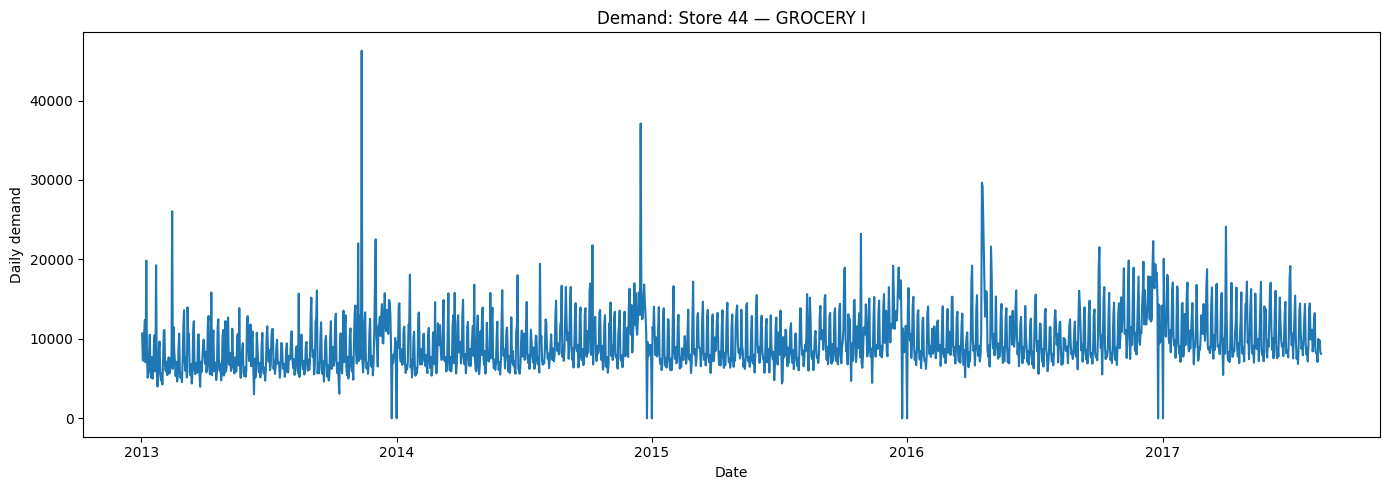

In [23]:
# Plot representative demand series

import matplotlib.pyplot as plt

top_store = int(series_summary.iloc[0]["store_nbr"])
top_family = series_summary.iloc[0]["family"]

representative_series = con.execute(f"""
SELECT
    date,
    target_demand_units
FROM read_parquet('{MODEL_BASE_PATH.as_posix()}')
WHERE store_nbr = {top_store}
  AND family = '{top_family}'
ORDER BY date
""").df()

representative_series["date"] = pd.to_datetime(
    representative_series["date"]
)

plt.figure(figsize=(14, 5))
plt.plot(
    representative_series["date"],
    representative_series["target_demand_units"]
)
plt.title(
    f"Demand: Store {top_store} — {top_family}"
)
plt.xlabel("Date")
plt.ylabel("Daily demand")
plt.tight_layout()
plt.show()

In [24]:
# Measure demand autocorrelation

series_values = representative_series[
    "target_demand_units"
].astype(float)

autocorrelation = pd.DataFrame({
    "lag": [1, 7, 14, 28, 364],
    "autocorrelation": [
        series_values.autocorr(lag=1),
        series_values.autocorr(lag=7),
        series_values.autocorr(lag=14),
        series_values.autocorr(lag=28),
        series_values.autocorr(lag=364)
    ]
})

display(autocorrelation)

,lag,autocorrelation
0,1,0.364329
1,7,0.507853
2,14,0.472918
3,28,0.447514
4,364,0.530103


In [25]:
# Compare baseline performance with LightGBM

baseline_summary = (
    baseline_results
    .groupby("model")[["MAE", "RMSE", "WAPE"]]
    .mean()
    .reset_index()
)

lightgbm_summary = pd.DataFrame([{
    "model": "LightGBM",
    "MAE": walk_forward_results["MAE"].mean(),
    "RMSE": walk_forward_results["RMSE"].mean(),
    "WAPE": walk_forward_results["WAPE"].mean()
}])

model_comparison = pd.concat(
    [baseline_summary, lightgbm_summary],
    ignore_index=True
)

display(model_comparison)

,model,MAE,RMSE,WAPE
0,Naive-1,131.139606,444.851586,0.254264
1,Seasonal-Naive-7,94.237478,336.778217,0.182692
2,LightGBM,61.257450,206.961940,0.118726


In [26]:
# Check forecast bias

bias_summary = error_analysis.assign(
    signed_error=lambda x:
        x[TARGET_COLUMN] - x["prediction"]
).agg(
    mean_error=("signed_error", "mean"),
    median_error=("signed_error", "median"),
    mean_actual=(TARGET_COLUMN, "mean"),
    mean_prediction=("prediction", "mean")
)

display(bias_summary)

,signed_error,target_demand_units,prediction
mean_error,-3.192475,NaN,NaN
median_error,-0.206200,NaN,NaN
mean_actual,NaN,514.579304,NaN
mean_prediction,NaN,NaN,517.771779


In [27]:
# Analyze errors by forecast horizon

horizon_error = (
    error_analysis
    .sort_values(["store_nbr", "family", "date"])
    .assign(
        forecast_horizon=lambda x:
            x.groupby(["store_nbr", "family"]).cumcount() + 1
    )
    .groupby("forecast_horizon")
    .agg(
        MAE=("absolute_error", "mean"),
        observations=("absolute_error", "size")
    )
    .reset_index()
)

display(horizon_error)

C:\Users\dell\AppData\Local\Temp\ipykernel_18088\131392590.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x.groupby(["store_nbr", "family"]).cumcount() + 1


,forecast_horizon,MAE,observations
0,1,43.346077,1683
1,2,48.786491,1683
2,3,74.705632,1682
3,4,73.726866,1681
4,5,81.701761,1681
5,6,48.748065,1681
6,7,47.706835,1680
7,8,49.000571,1679
8,9,49.654535,1678
9,10,63.434468,1678


In [8]:
# Verify future feature availability

TEST_PATH = RAW_DIR / "test.csv"

future_features = con.execute(f"""
SELECT
    MIN(CAST(date AS DATE)) AS forecast_start,
    MAX(CAST(date AS DATE)) AS forecast_end,
    COUNT(DISTINCT CAST(date AS DATE)) AS forecast_days,
    SUM(CASE WHEN onpromotion IS NULL THEN 1 ELSE 0 END) AS missing_promotion_rows,
    COUNT(*) AS test_rows
FROM read_csv_auto('{TEST_PATH.as_posix()}')
""").df()

display(future_features)

,forecast_start,forecast_end,forecast_days,missing_promotion_rows,test_rows
0,2017-08-16,2017-08-31,16,0.0,3370464


In [9]:
# Check external feature availability during forecast horizon

future_external = con.execute(f"""
SELECT
    MIN(date) AS start_date,
    MAX(date) AS end_date,
    COUNT(*) AS oil_dates,
    SUM(oil_missing) AS oil_missing_dates
FROM read_parquet('{(PROCESSED_DIR / "oil_clean.parquet").as_posix()}')
WHERE date BETWEEN
    (SELECT MIN(CAST(date AS DATE)) FROM read_csv_auto('{TEST_PATH.as_posix()}'))
    AND
    (SELECT MAX(CAST(date AS DATE)) FROM read_csv_auto('{TEST_PATH.as_posix()}'))
""").df()

display(future_external)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,start_date,end_date,oil_dates,oil_missing_dates
0,2017-08-16,2017-08-31,12,0.0


In [10]:
# Understand the 16-day recursive forecasting process

print("""
Our final forecast horizon is 16 days.

Day 1:
  Historical actuals → predict Day 1

Day 2:
  Historical actuals + Day 1 prediction → predict Day 2

Day 3:
  Historical actuals + Day 1/2 predictions → predict Day 3

...

Day 16:
  Historical actuals + previous predictions → predict Day 16

This is recursive multi-step forecasting.

Important:
  Known future features:
    - calendar
    - weekday
    - holiday
    - store
    - product family
    - test promotions

  Unknown future values:
    - demand
    - lagged demand that depends on future predictions
""")


Our final forecast horizon is 16 days.

Day 1:
  Historical actuals → predict Day 1

Day 2:
  Historical actuals + Day 1 prediction → predict Day 2

Day 3:
  Historical actuals + Day 1/2 predictions → predict Day 3

...

Day 16:
  Historical actuals + previous predictions → predict Day 16

This is recursive multi-step forecasting.

Important:
  Known future features:
    - calendar
    - weekday
    - holiday
    - store
    - product family
    - test promotions

  Unknown future values:
    - demand
    - lagged demand that depends on future predictions



In [11]:
# Verify the actual forecasting horizon

test_horizon = con.execute(f"""
SELECT
    MIN(CAST(date AS DATE)) AS first_forecast_date,
    MAX(CAST(date AS DATE)) AS last_forecast_date,
    COUNT(DISTINCT CAST(date AS DATE)) AS forecast_days
FROM read_csv_auto('{(RAW_DIR / "test.csv").as_posix()}')
""").df()

display(test_horizon)

,first_forecast_date,last_forecast_date,forecast_days
0,2017-08-16,2017-08-31,16


In [12]:
# Confirm forecasting stage

print("Historical model data:")
print(con.execute(f"""
    SELECT
        MIN(date) AS start_date,
        MAX(date) AS end_date,
        COUNT(*) AS rows,
        COUNT(DISTINCT store_nbr) AS stores,
        COUNT(DISTINCT family) AS families
    FROM read_parquet('{MODEL_BASE_PATH.as_posix()}')
""").df())

print("\nForecast feature data:")
print(con.execute(f"""
    SELECT
        MIN(date) AS start_date,
        MAX(date) AS end_date,
        COUNT(*) AS rows
    FROM read_parquet('{FEATURES_PATH.as_posix()}')
""").df())

Historical model data:
  start_date   end_date     rows  stores  families
0 2013-01-01 2017-08-15  2436459      54        33

Forecast feature data:
  start_date   end_date     rows
0 2013-01-01 2017-08-15  2436459


In [13]:
# Verify forecast horizon

TEST_PATH = RAW_DIR / "test.csv"

test_horizon = con.execute(f"""
SELECT
    MIN(CAST(date AS DATE)) AS first_forecast_date,
    MAX(CAST(date AS DATE)) AS last_forecast_date,
    COUNT(DISTINCT CAST(date AS DATE)) AS forecast_days,
    COUNT(*) AS test_rows
FROM read_csv_auto('{TEST_PATH.as_posix()}')
""").df()

display(test_horizon)

,first_forecast_date,last_forecast_date,forecast_days,test_rows
0,2017-08-16,2017-08-31,16,3370464


In [14]:
# Verify historical boundary

forecast_boundary = con.execute(f"""
SELECT
    MAX(date) AS historical_last_date,
    DATE '{test_horizon.loc[0, "first_forecast_date"]}' AS forecast_first_date,
    DATE '{test_horizon.loc[0, "first_forecast_date"]}' - MAX(date) AS gap_days
FROM read_parquet('{MODEL_BASE_PATH.as_posix()}')
""").df()

display(forecast_boundary)

,historical_last_date,forecast_first_date,gap_days
0,2017-08-15,2017-08-16,1


In [15]:
# Build future forecasting features

future_features = con.execute(f"""
WITH test_data AS (
    SELECT
        CAST(t.date AS DATE) AS date,
        t.store_nbr,
        i.family,
        t.onpromotion
    FROM read_csv_auto('{TEST_PATH.as_posix()}') t
    INNER JOIN read_csv_auto('{(RAW_DIR / "items.csv").as_posix()}') i
        ON t.item_nbr = i.item_nbr
),
daily_family AS (
    SELECT
        date,
        store_nbr,
        family,
        COUNT(*) AS item_records,
        COUNT(onpromotion) AS promotion_known_records,
        SUM(
            CASE
                WHEN onpromotion = TRUE THEN 1
                ELSE 0
            END
        ) AS promoted_records
    FROM test_data
    GROUP BY date, store_nbr, family
)
SELECT
    d.date,
    d.store_nbr,
    d.family,
    d.promotion_known_records,
    d.promoted_records,

    CASE
        WHEN d.promotion_known_records > 0
        THEN d.promoted_records * 1.0 / d.promotion_known_records
        ELSE NULL
    END AS promotion_rate,

    CASE
        WHEN d.promotion_known_records > 0 THEN 1
        ELSE 0
    END AS promotion_data_available,

    EXTRACT(DAYOFWEEK FROM d.date) - 1 AS day_of_week,
    EXTRACT(DAY FROM d.date) AS day_of_month,
    EXTRACT(MONTH FROM d.date) AS month,
    EXTRACT(QUARTER FROM d.date) AS quarter,
    EXTRACT(YEAR FROM d.date) AS year,
    EXTRACT(WEEK FROM d.date) AS week_of_year,

    CASE
        WHEN EXTRACT(DAYOFWEEK FROM d.date) IN (0, 6) THEN 1
        ELSE 0
    END AS is_weekend

FROM daily_family d
ORDER BY d.date, d.store_nbr, d.family
""").df()

print("Rows:", len(future_features))
print("Date range:", future_features["date"].min(), "to", future_features["date"].max())
print("Stores:", future_features["store_nbr"].nunique())
print("Families:", future_features["family"].nunique())

display(future_features.head())

Task was destroyed but it is pending!
task: <Task pending name='Task-247' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at C:\Users\dell\anaconda3\envs\freshml\lib\site-packages\ipykernel\utils.py:76> wait_for=<Task pending name='Task-248' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\dell\anaconda3\envs\freshml\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\dell\anaconda3\envs\freshml\lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\dell\anaconda3\envs\freshml\lib\site-packages\pandas\core\indexes\base.py:671: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  result._references.add_index_reference(result)
Task was destroyed but it is pending!
task: <Task pending name='Task-248' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\dell\anaconda3\envs\freshml\lib\site-packages\ipykernel

Rows: 28512
Date range: 2017-08-16 00:00:00 to 2017-08-31 00:00:00
Stores: 54
Families: 33


,date,store_nbr,family,promotion_known_records,promoted_records,promotion_rate,promotion_data_available,day_of_week,day_of_month,month,quarter,year,week_of_year,is_weekend
0,2017-08-16,1,AUTOMOTIVE,20,0.0,0.000000,1,2,16,8,3,2017,33,0
1,2017-08-16,1,BABY CARE,1,0.0,0.000000,1,2,16,8,3,2017,33,0
2,2017-08-16,1,BEAUTY,8,2.0,0.250000,1,2,16,8,3,2017,33,0
3,2017-08-16,1,BEVERAGES,560,20.0,0.035714,1,2,16,8,3,2017,33,0
4,2017-08-16,1,BOOKS,1,0.0,0.000000,1,2,16,8,3,2017,33,0


In [16]:
# Add future holiday and oil features

HOLIDAY_CALENDAR_PATH = PROCESSED_DIR / "holiday_calendar.parquet"
OIL_CLEAN_PATH = PROCESSED_DIR / "oil_clean.parquet"

future_features = con.execute(f"""
SELECT
    f.*,
    COALESCE(h.is_holiday, 0) AS is_holiday,
    o.dcoilwtico_filled AS oil_price,
    COALESCE(o.oil_missing, 0) AS oil_missing
FROM future_features f
LEFT JOIN read_parquet('{HOLIDAY_CALENDAR_PATH.as_posix()}') h
    ON f.date = h.date
LEFT JOIN read_parquet('{OIL_CLEAN_PATH.as_posix()}') o
    ON f.date = o.date
ORDER BY f.date, f.store_nbr, f.family
""").df()

print("Rows:", len(future_features))
print("Date range:", future_features["date"].min(), "to", future_features["date"].max())
print("Holiday dates:", future_features.loc[future_features["is_holiday"] == 1, "date"].nunique())
print("Missing oil values:", future_features["oil_price"].isna().sum())

display(future_features.head())

Rows: 28512
Date range: 2017-08-16 00:00:00 to 2017-08-31 00:00:00
Holiday dates: 1
Missing oil values: 7128


,date,store_nbr,family,promotion_known_records,promoted_records,promotion_rate,promotion_data_available,day_of_week,day_of_month,month,quarter,year,week_of_year,is_weekend,is_holiday,oil_price,oil_missing
0,2017-08-16,1,AUTOMOTIVE,20,0.0,0.000000,1,2,16,8,3,2017,33,0,0,46.8,0
1,2017-08-16,1,BABY CARE,1,0.0,0.000000,1,2,16,8,3,2017,33,0,0,46.8,0
2,2017-08-16,1,BEAUTY,8,2.0,0.250000,1,2,16,8,3,2017,33,0,0,46.8,0
3,2017-08-16,1,BEVERAGES,560,20.0,0.035714,1,2,16,8,3,2017,33,0,0,46.8,0
4,2017-08-16,1,BOOKS,1,0.0,0.000000,1,2,16,8,3,2017,33,0,0,46.8,0


In [17]:
# Add future holiday and oil features

HOLIDAY_CALENDAR_PATH = PROCESSED_DIR / "holiday_calendar.parquet"
OIL_CLEAN_PATH = PROCESSED_DIR / "oil_clean.parquet"

future_features = con.execute(f"""
SELECT
    f.*,
    COALESCE(h.is_holiday, 0) AS is_holiday,
    o.dcoilwtico_filled AS oil_price,
    COALESCE(o.oil_missing, 0) AS oil_missing
FROM future_features f
LEFT JOIN read_parquet('{HOLIDAY_CALENDAR_PATH.as_posix()}') h
    ON f.date = h.date
LEFT JOIN read_parquet('{OIL_CLEAN_PATH.as_posix()}') o
    ON f.date = o.date
ORDER BY f.date, f.store_nbr, f.family
""").df()

print("Rows:", len(future_features))
print("Date range:", future_features["date"].min(), "to", future_features["date"].max())
print("Holiday dates:", future_features.loc[future_features["is_holiday"] == 1, "date"].nunique())
print("Missing oil values:", future_features["oil_price"].isna().sum())

display(future_features.head())

Rows: 28512
Date range: 2017-08-16 00:00:00 to 2017-08-31 00:00:00
Holiday dates: 1
Missing oil values: 7128


,date,store_nbr,family,promotion_known_records,promoted_records,promotion_rate,promotion_data_available,day_of_week,day_of_month,month,quarter,year,week_of_year,is_weekend,is_holiday,oil_price,oil_missing,is_holiday_1,oil_price_1,oil_missing_1
0,2017-08-16,1,AUTOMOTIVE,20,0.0,0.000000,1,2,16,8,3,2017,33,0,0,46.8,0,0,46.8,0
1,2017-08-16,1,BABY CARE,1,0.0,0.000000,1,2,16,8,3,2017,33,0,0,46.8,0,0,46.8,0
2,2017-08-16,1,BEAUTY,8,2.0,0.250000,1,2,16,8,3,2017,33,0,0,46.8,0,0,46.8,0
3,2017-08-16,1,BEVERAGES,560,20.0,0.035714,1,2,16,8,3,2017,33,0,0,46.8,0,0,46.8,0
4,2017-08-16,1,BOOKS,1,0.0,0.000000,1,2,16,8,3,2017,33,0,0,46.8,0,0,46.8,0


In [18]:
# Add future holiday and oil features

HOLIDAY_CALENDAR_PATH = PROCESSED_DIR / "holiday_calendar.parquet"
OIL_CLEAN_PATH = PROCESSED_DIR / "oil_clean.parquet"

future_features = con.execute(f"""
SELECT
    f.*,
    COALESCE(h.is_holiday, 0) AS is_holiday,
    o.dcoilwtico_filled AS oil_price,
    COALESCE(o.oil_missing, 0) AS oil_missing
FROM future_features f
LEFT JOIN read_parquet('{HOLIDAY_CALENDAR_PATH.as_posix()}') h
    ON f.date = h.date
LEFT JOIN read_parquet('{OIL_CLEAN_PATH.as_posix()}') o
    ON f.date = o.date
ORDER BY f.date, f.store_nbr, f.family
""").df()

print("Rows:", len(future_features))
print("Date range:", future_features["date"].min(), "to", future_features["date"].max())
print("Holiday dates:", future_features.loc[future_features["is_holiday"] == 1, "date"].nunique())
print("Missing oil values:", future_features["oil_price"].isna().sum())

display(future_features.head())

Rows: 28512
Date range: 2017-08-16 00:00:00 to 2017-08-31 00:00:00
Holiday dates: 1
Missing oil values: 7128


,date,store_nbr,family,promotion_known_records,promoted_records,promotion_rate,promotion_data_available,day_of_week,day_of_month,month,...,is_weekend,is_holiday,oil_price,oil_missing,is_holiday_1,oil_price_1,oil_missing_1,is_holiday_2,oil_price_2,oil_missing_2
0,2017-08-16,1,AUTOMOTIVE,20,0.0,0.000000,1,2,16,8,...,0,0,46.8,0,0,46.8,0,0,46.8,0
1,2017-08-16,1,BABY CARE,1,0.0,0.000000,1,2,16,8,...,0,0,46.8,0,0,46.8,0,0,46.8,0
2,2017-08-16,1,BEAUTY,8,2.0,0.250000,1,2,16,8,...,0,0,46.8,0,0,46.8,0,0,46.8,0
3,2017-08-16,1,BEVERAGES,560,20.0,0.035714,1,2,16,8,...,0,0,46.8,0,0,46.8,0,0,46.8,0
4,2017-08-16,1,BOOKS,1,0.0,0.000000,1,2,16,8,...,0,0,46.8,0,0,46.8,0,0,46.8,0


In [20]:
# Prepare historical demand lookup

history_start = pd.Timestamp(
    test_horizon.loc[0, "first_forecast_date"]
) - pd.Timedelta(days=400)

history = con.execute(f"""
SELECT
    date,
    store_nbr,
    family,
    target_demand_units
FROM read_parquet('{MODEL_BASE_PATH.as_posix()}')
WHERE date >= DATE '{history_start.strftime("%Y-%m-%d")}'
ORDER BY store_nbr, family, date
""").df()

history["date"] = pd.to_datetime(history["date"])

history_lookup = {}

for (store, family), group in history.groupby(
    ["store_nbr", "family"], sort=False
):
    series = group.set_index("date")["target_demand_units"].sort_index()
    history_lookup[(int(store), family)] = series.to_dict()

future_series = set(
    zip(
        future_features["store_nbr"].astype(int),
        future_features["family"]
    )
)

missing_history_series = [
    key for key in future_series
    if key not in history_lookup
]

print("History rows:", len(history))
print("History range:", history["date"].min(), "to", history["date"].max())
print("Historical series:", len(history_lookup))
print("Forecast series:", len(future_series))
print("Missing historical series:", len(missing_history_series))

if missing_history_series:
    print("Examples:", missing_history_series[:10])

History rows: 668499
History range: 2016-07-12 00:00:00 to 2017-08-15 00:00:00
Historical series: 1718
Forecast series: 1782
Missing historical series: 64
Examples: [(22, 'BOOKS'), (44, 'BABY CARE'), (52, 'BOOKS'), (33, 'BOOKS'), (14, 'LAWN AND GARDEN'), (47, 'BABY CARE'), (36, 'BOOKS'), (17, 'BOOKS'), (1, 'BABY CARE'), (39, 'BOOKS')]


In [22]:
# Fix LightGBM feature types and rerun recursive forecast

import joblib

model = joblib.load(MODEL_PATH)

# The saved model was trained with family categorical and store_nbr numeric
family_categories = model.booster_.pandas_categorical[0]

future_features["store_nbr"] = future_features["store_nbr"].astype(int)
future_features["family"] = future_features["family"].astype(
    pd.CategoricalDtype(categories=family_categories)
)

forecast_rows = []

for forecast_date in sorted(future_features["date"].unique()):

    day_features = future_features[
        future_features["date"] == forecast_date
    ].copy()

    feature_rows = []

    for _, row in day_features.iterrows():

        store = int(row["store_nbr"])
        family = row["family"]
        key = (store, family)

        series_history = history_lookup.get(key, {})

        lag_1 = series_history.get(
            forecast_date - pd.Timedelta(days=1), np.nan
        )
        lag_7 = series_history.get(
            forecast_date - pd.Timedelta(days=7), np.nan
        )
        lag_14 = series_history.get(
            forecast_date - pd.Timedelta(days=14), np.nan
        )
        lag_28 = series_history.get(
            forecast_date - pd.Timedelta(days=28), np.nan
        )
        lag_364 = series_history.get(
            forecast_date - pd.Timedelta(days=364), np.nan
        )

        previous_7 = [
            series_history[d]
            for d in pd.date_range(
                forecast_date - pd.Timedelta(days=7),
                forecast_date - pd.Timedelta(days=1)
            )
            if d in series_history
        ]

        previous_28 = [
            series_history[d]
            for d in pd.date_range(
                forecast_date - pd.Timedelta(days=28),
                forecast_date - pd.Timedelta(days=1)
            )
            if d in series_history
        ]

        feature_rows.append({
            **row.to_dict(),
            "store_nbr": store,
            "family": family,
            "lag_1": lag_1,
            "lag_7": lag_7,
            "lag_14": lag_14,
            "lag_28": lag_28,
            "lag_364": lag_364,
            "rolling_mean_7": np.mean(previous_7) if previous_7 else np.nan,
            "rolling_mean_28": np.mean(previous_28) if previous_28 else np.nan,
            "rolling_std_28": (
                np.std(previous_28, ddof=1)
                if len(previous_28) > 1
                else np.nan
            )
        })

    day_model_data = pd.DataFrame(feature_rows)

    X_day = day_model_data[FEATURE_COLUMNS].copy()

    X_day["store_nbr"] = X_day["store_nbr"].astype(int)

    X_day["family"] = X_day["family"].astype(
        pd.CategoricalDtype(categories=family_categories)
    )

    predictions = model.predict(X_day)
    predictions = np.maximum(predictions, 0)

    day_model_data["forecast_demand_units"] = predictions

    for _, pred_row in day_model_data.iterrows():
        key = (int(pred_row["store_nbr"]), pred_row["family"])

        history_lookup.setdefault(key, {})[forecast_date] = float(
            pred_row["forecast_demand_units"]
        )

    forecast_rows.append(
        day_model_data[
            [
                "date",
                "store_nbr",
                "family",
                "forecast_demand_units"
            ]
        ]
    )

    print(
        forecast_date.date(),
        "completed:",
        len(day_model_data),
        "series"
    )

test_forecast = pd.concat(
    forecast_rows,
    ignore_index=True
)

display(test_forecast.head())

print("Forecast rows:", len(test_forecast))
print(
    "Forecast dates:",
    test_forecast["date"].min(),
    "to",
    test_forecast["date"].max()
)

2017-08-16 completed: 1782 series
2017-08-17 completed: 1782 series
2017-08-18 completed: 1782 series
2017-08-19 completed: 1782 series
2017-08-20 completed: 1782 series
2017-08-21 completed: 1782 series
2017-08-22 completed: 1782 series
2017-08-23 completed: 1782 series
2017-08-24 completed: 1782 series
2017-08-25 completed: 1782 series
2017-08-26 completed: 1782 series
2017-08-27 completed: 1782 series
2017-08-28 completed: 1782 series
2017-08-29 completed: 1782 series
2017-08-30 completed: 1782 series
2017-08-31 completed: 1782 series


,date,store_nbr,family,forecast_demand_units
0,2017-08-16,1,AUTOMOTIVE,3.656327
1,2017-08-16,1,BABY CARE,1.996696
2,2017-08-16,1,BEAUTY,5.491486
3,2017-08-16,1,BEVERAGES,2163.304201
4,2017-08-16,1,BOOKS,1.996696


Forecast rows: 28512
Forecast dates: 2017-08-16 00:00:00 to 2017-08-31 00:00:00


In [23]:
# Validate forecast series against historical series

historical_series = set(
    zip(
        history["store_nbr"].astype(int),
        history["family"]
    )
)

forecast_series = set(
    zip(
        test_forecast["store_nbr"].astype(int),
        test_forecast["family"]
    )
)

new_series = forecast_series - historical_series

print("Historical series:", len(historical_series))
print("Forecast series:", len(forecast_series))
print("Forecast series with historical data:", len(forecast_series & historical_series))
print("Forecast series without historical data:", len(new_series))

if new_series:
    print("\nExamples of series without historical demand:")
    print(list(new_series)[:20])

Historical series: 1718
Forecast series: 1782
Forecast series with historical data: 1718
Forecast series without historical data: 64

Examples of series without historical demand:
[(22, 'BOOKS'), (22, 'LAWN AND GARDEN'), (49, 'BABY CARE'), (9, 'BOOKS'), (28, 'LADIESWEAR'), (11, 'BOOKS'), (33, 'BOOKS'), (32, 'LADIESWEAR'), (33, 'LAWN AND GARDEN'), (43, 'LADIESWEAR'), (13, 'BOOKS'), (35, 'BOOKS'), (13, 'LAWN AND GARDEN'), (35, 'LAWN AND GARDEN'), (15, 'BOOKS'), (15, 'LAWN AND GARDEN'), (39, 'BOOKS'), (44, 'BABY CARE'), (54, 'LADIESWEAR'), (13, 'BABY CARE')]


In [24]:
# Validate complete historical series

full_historical_series = con.execute(f"""
SELECT
    COUNT(*) AS series_count
FROM (
    SELECT DISTINCT
        store_nbr,
        family
    FROM read_parquet('{MODEL_BASE_PATH.as_posix()}')
)
""").df()

display(full_historical_series)

,series_count
0,1729


In [25]:
# Compare complete historical series with forecast series

historical_series_full = set(
    tuple(x)
    for x in con.execute(f"""
        SELECT DISTINCT store_nbr, family
        FROM read_parquet('{MODEL_BASE_PATH.as_posix()}')
    """).fetchall()
)

forecast_series = set(
    zip(
        test_forecast["store_nbr"].astype(int),
        test_forecast["family"].astype(str)
    )
)

historical_series_full = {
    (int(store), str(family))
    for store, family in historical_series_full
}

new_series = forecast_series - historical_series_full

print("Complete historical series:", len(historical_series_full))
print("Forecast series:", len(forecast_series))
print("Forecast series with history:", len(forecast_series & historical_series_full))
print("Forecast series without history:", len(new_series))

Complete historical series: 1729
Forecast series: 1782
Forecast series with history: 1729
Forecast series without history: 53


In [26]:
# Inspect forecast-only series

if new_series:
    new_series_df = pd.DataFrame(
        list(new_series),
        columns=["store_nbr", "family"]
    ).sort_values(["store_nbr", "family"])

    display(new_series_df.head(20))
else:
    print("No forecast-only series found.")

,store_nbr,family
39,1,BABY CARE
2,9,BOOKS
24,10,BOOKS
4,11,BOOKS
34,12,BOOKS
14,13,BABY CARE
8,13,BOOKS
38,14,BOOKS
41,14,LAWN AND GARDEN
10,15,BOOKS


In [27]:
# Keep only historically active series

valid_forecast_series = pd.DataFrame(
    list(historical_series_full),
    columns=["store_nbr", "family"]
)

valid_forecast_series["store_nbr"] = valid_forecast_series["store_nbr"].astype(int)

test_forecast_valid = test_forecast.merge(
    valid_forecast_series,
    on=["store_nbr", "family"],
    how="inner"
)

print("Original forecast rows:", len(test_forecast))
print("Valid forecast rows:", len(test_forecast_valid))
print("Forecast series retained:",
      test_forecast_valid[["store_nbr", "family"]].drop_duplicates().shape[0])
print(
    "Expected rows:",
    len(valid_forecast_series) * test_horizon.loc[0, "forecast_days"]
)

display(test_forecast_valid.head())

Original forecast rows: 28512
Valid forecast rows: 27664
Forecast series retained: 1729
Expected rows: 27664


,date,store_nbr,family,forecast_demand_units
0,2017-08-16,1,AUTOMOTIVE,3.656327
1,2017-08-16,1,BEAUTY,5.491486
2,2017-08-16,1,BEVERAGES,2163.304201
3,2017-08-16,1,BOOKS,1.996696
4,2017-08-16,1,BREAD/BAKERY,360.006649


In [28]:
# Identify cold-start forecast series

cold_start_series = pd.DataFrame(
    list(new_series),
    columns=["store_nbr", "family"]
)

cold_start_series["store_nbr"] = cold_start_series["store_nbr"].astype(int)

print("Cold-start series:", len(cold_start_series))
display(cold_start_series.head(20))

Cold-start series: 53


,store_nbr,family
0,22,BOOKS
1,49,BABY CARE
2,9,BOOKS
3,28,LADIESWEAR
4,11,BOOKS
5,33,BOOKS
6,32,LADIESWEAR
7,43,LADIESWEAR
8,13,BOOKS
9,35,BOOKS


In [29]:
# Create zero forecasts for cold-start series

cold_start_dates = pd.DataFrame({
    "date": pd.to_datetime(
        sorted(test_forecast["date"].unique())
    )
})

cold_start_forecast = (
    cold_start_series
    .merge(cold_start_dates, how="cross")
)

cold_start_forecast["forecast_demand_units"] = 0.0

print("Cold-start forecast rows:", len(cold_start_forecast))
display(cold_start_forecast.head())

Cold-start forecast rows: 848


,store_nbr,family,date,forecast_demand_units
0,22,BOOKS,2017-08-16,0.0
1,22,BOOKS,2017-08-17,0.0
2,22,BOOKS,2017-08-18,0.0
3,22,BOOKS,2017-08-19,0.0
4,22,BOOKS,2017-08-20,0.0


In [30]:
# Combine historical and cold-start forecasts

test_forecast_final = pd.concat(
    [
        test_forecast_valid[
            [
                "date",
                "store_nbr",
                "family",
                "forecast_demand_units"
            ]
        ],
        cold_start_forecast[
            [
                "date",
                "store_nbr",
                "family",
                "forecast_demand_units"
            ]
        ]
    ],
    ignore_index=True
)

test_forecast_final = test_forecast_final.sort_values(
    ["date", "store_nbr", "family"]
).reset_index(drop=True)

print("Final forecast rows:", len(test_forecast_final))
print(
    "Final forecast series:",
    test_forecast_final[["store_nbr", "family"]].drop_duplicates().shape[0]
)# Validate final forecast

expected_rows = (
    len(forecast_series)
    * int(test_horizon.loc[0, "forecast_days"])
)

print("Expected rows:", expected_rows)
print("Actual rows:", len(test_forecast_final))
print("Null predictions:", test_forecast_final["forecast_demand_units"].isna().sum())
print("Negative predictions:", (test_forecast_final["forecast_demand_units"] < 0).sum())
print("Unique dates:", test_forecast_final["date"].nunique())
print("Unique series:", test_forecast_final[["store_nbr", "family"]].drop_duplicates().shape[0])

assert len(test_forecast_final) == expected_rows
assert test_forecast_final["forecast_demand_units"].isna().sum() == 0
assert (test_forecast_final["forecast_demand_units"] < 0).sum() == 0

display(test_forecast_final.head(10))

Final forecast rows: 28512
Final forecast series: 1782
Expected rows: 28512
Actual rows: 28512
Null predictions: 0
Negative predictions: 0
Unique dates: 16
Unique series: 1782


,date,store_nbr,family,forecast_demand_units
0,2017-08-16,1,AUTOMOTIVE,3.656327
1,2017-08-16,1,BABY CARE,0.000000
2,2017-08-16,1,BEAUTY,5.491486
3,2017-08-16,1,BEVERAGES,2163.304201
4,2017-08-16,1,BOOKS,1.996696
5,2017-08-16,1,BREAD/BAKERY,360.006649
6,2017-08-16,1,CELEBRATION,8.627624
7,2017-08-16,1,CLEANING,680.689193
8,2017-08-16,1,DAIRY,711.255242
9,2017-08-16,1,DELI,116.052296


In [31]:
# Save final forecast

FORECAST_PATH = PROCESSED_DIR / "test_store_family_forecast.parquet"

test_forecast_final.to_parquet(
    FORECAST_PATH,
    index=False
)

print("Saved:", FORECAST_PATH)
print("File exists:", FORECAST_PATH.exists())

Saved: C:\Users\dell\demand-forecasting-inventory\data\processed\test_store_family_forecast.parquet
File exists: True


In [32]:
# Verify saved forecast

saved_forecast = con.execute(f"""
SELECT
    MIN(date) AS first_date,
    MAX(date) AS last_date,
    COUNT(*) AS rows,
    COUNT(DISTINCT store_nbr) AS stores,
    COUNT(DISTINCT family) AS families,
    COUNT(DISTINCT date) AS dates,
    SUM(forecast_demand_units) AS total_forecast_units
FROM read_parquet('{FORECAST_PATH.as_posix()}')
""").df()

display(saved_forecast)

,first_date,last_date,rows,stores,families,dates,total_forecast_units
0,2017-08-16,2017-08-31,28512,54,33,16,1.220155e+07


In [33]:
# Check forecast distribution

forecast_distribution = con.execute(f"""
SELECT
    AVG(forecast_demand_units) AS mean_forecast,
    MEDIAN(forecast_demand_units) AS median_forecast,
    MIN(forecast_demand_units) AS minimum_forecast,
    MAX(forecast_demand_units) AS maximum_forecast,
    SUM(
        CASE WHEN forecast_demand_units = 0 THEN 1 ELSE 0 END
    ) AS zero_forecasts
FROM read_parquet('{FORECAST_PATH.as_posix()}')
""").df()

display(forecast_distribution)

,mean_forecast,median_forecast,minimum_forecast,maximum_forecast,zero_forecasts
0,427.944531,22.442662,0.0,14119.208833,848.0


In [34]:
# Check daily forecast stability

daily_forecast = con.execute(f"""
SELECT
    date,
    SUM(forecast_demand_units) AS total_forecast_units,
    AVG(forecast_demand_units) AS average_series_forecast
FROM read_parquet('{FORECAST_PATH.as_posix()}')
GROUP BY date
ORDER BY date
""").df()

display(daily_forecast)

,date,total_forecast_units,average_series_forecast
0,2017-08-16,763340.814508,428.361849
1,2017-08-17,663032.610750,372.072172
2,2017-08-18,723345.329346,405.917693
3,2017-08-19,889149.957492,498.961817
4,2017-08-20,959173.721073,538.256858
5,2017-08-21,766261.329422,430.000746
6,2017-08-22,705823.252774,396.084878
7,2017-08-23,715869.484593,401.722494
8,2017-08-24,639871.516989,359.074925
9,2017-08-25,684537.348758,384.139926


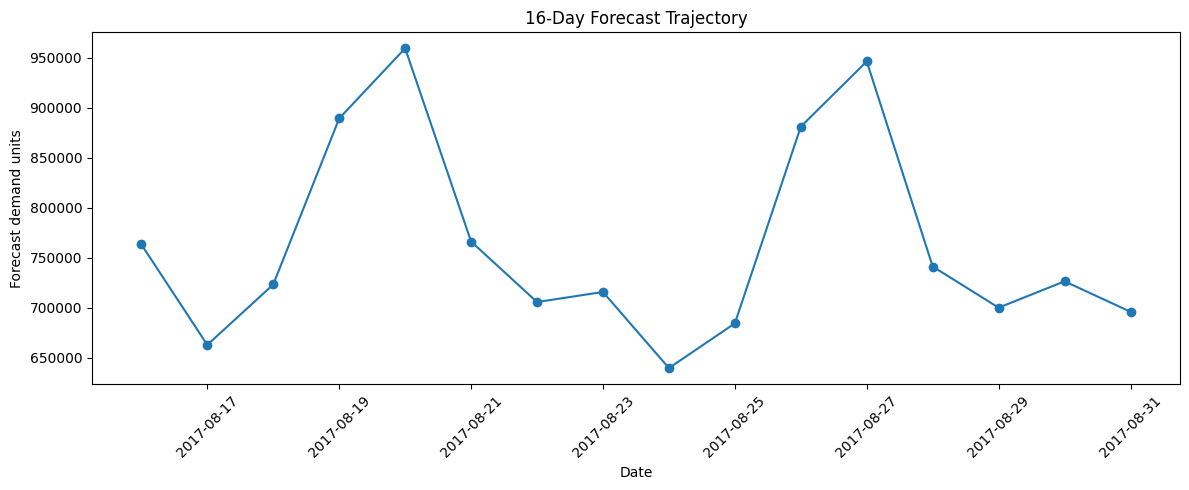

In [35]:
# Plot forecast trajectory

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(
    daily_forecast["date"],
    daily_forecast["total_forecast_units"],
    marker="o"
)
plt.xlabel("Date")
plt.ylabel("Forecast demand units")
plt.title("16-Day Forecast Trajectory")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# Check day-to-day forecast changes

daily_forecast["pct_change"] = (
    daily_forecast["total_forecast_units"]
    .pct_change() * 100
)

display(
    daily_forecast[
        ["date", "total_forecast_units", "pct_change"]
    ]
)

,date,total_forecast_units,pct_change
0,2017-08-16,763340.814508,NaN
1,2017-08-17,663032.610750,-13.140684
2,2017-08-18,723345.329346,9.096494
3,2017-08-19,889149.957492,22.921919
4,2017-08-20,959173.721073,7.875360
5,2017-08-21,766261.329422,-20.112352
6,2017-08-22,705823.252774,-7.887397
7,2017-08-23,715869.484593,1.423335
8,2017-08-24,639871.516989,-10.616176
9,2017-08-25,684537.348758,6.980438


In [37]:
# Identify highest-demand forecast series

top_forecast_series = con.execute(f"""
SELECT
    store_nbr,
    family,
    SUM(forecast_demand_units) AS forecast_units,
    AVG(forecast_demand_units) AS avg_daily_forecast
FROM read_parquet('{FORECAST_PATH.as_posix()}')
GROUP BY store_nbr, family
ORDER BY forecast_units DESC
LIMIT 20
""").df()

display(top_forecast_series)

,store_nbr,family,forecast_units,avg_daily_forecast
0,45,GROCERY I,157457.709595,9841.106850
1,44,PRODUCE,147625.067102,9226.566694
2,44,BEVERAGES,146405.974754,9150.373422
3,44,GROCERY I,145770.088625,9110.630539
4,47,GROCERY I,144475.647064,9029.727942
5,45,BEVERAGES,135413.305532,8463.331596
6,46,GROCERY I,131782.014084,8236.375880
7,47,BEVERAGES,124040.529895,7752.533118
8,3,BEVERAGES,123970.698439,7748.168652
9,49,PRODUCE,119657.913043,7478.619565


In [38]:
# Check forecast concentration

concentration = con.execute(f"""
WITH series_totals AS (
    SELECT
        store_nbr,
        family,
        SUM(forecast_demand_units) AS forecast_units
    FROM read_parquet('{FORECAST_PATH.as_posix()}')
    GROUP BY store_nbr, family
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            ORDER BY forecast_units DESC
        ) AS rank
    FROM series_totals
)
SELECT
    SUM(forecast_units) AS total_forecast,
    SUM(CASE WHEN rank <= 10 THEN forecast_units ELSE 0 END)
        / SUM(forecast_units) AS top_10_share,
    SUM(CASE WHEN rank <= 50 THEN forecast_units ELSE 0 END)
        / SUM(forecast_units) AS top_50_share
FROM ranked
""").df()

display(concentration)

,total_forecast,top_10_share,top_50_share
0,1.220155e+07,0.112822,0.378476


In [39]:
# Compare forecast with recent historical demand

recent_history = con.execute(f"""
SELECT
    date,
    SUM(target_demand_units) AS historical_demand
FROM read_parquet('{MODEL_BASE_PATH.as_posix()}')
WHERE date BETWEEN DATE '2017-07-31' AND DATE '2017-08-15'
GROUP BY date
ORDER BY date
""").df()

recent_history["date"] = pd.to_datetime(recent_history["date"])

display(recent_history)

,date,historical_demand
0,2017-07-31,885872.841
1,2017-08-01,988610.763
2,2017-08-02,964762.016
3,2017-08-03,728081.485
4,2017-08-04,827780.686
5,2017-08-05,965699.650
6,2017-08-06,1049580.164
7,2017-08-07,797496.998
8,2017-08-08,717796.736
9,2017-08-09,734152.674


In [40]:
# Compare daily forecast with recent history

comparison = daily_forecast[
    ["date", "total_forecast_units"]
].merge(
    recent_history,
    on="date",
    how="left"
)

comparison["forecast_vs_history_pct"] = (
    comparison["total_forecast_units"]
    / comparison["historical_demand"]
    - 1
) * 100

display(comparison)

,date,total_forecast_units,historical_demand,forecast_vs_history_pct
0,2017-08-16,763340.814508,NaN,NaN
1,2017-08-17,663032.610750,NaN,NaN
2,2017-08-18,723345.329346,NaN,NaN
3,2017-08-19,889149.957492,NaN,NaN
4,2017-08-20,959173.721073,NaN,NaN
5,2017-08-21,766261.329422,NaN,NaN
6,2017-08-22,705823.252774,NaN,NaN
7,2017-08-23,715869.484593,NaN,NaN
8,2017-08-24,639871.516989,NaN,NaN
9,2017-08-25,684537.348758,NaN,NaN


In [41]:
# Compare aggregate demand levels

summary_comparison = pd.DataFrame({
    "period": [
        "Recent 16-day history",
        "Forecast 16 days"
    ],
    "total_units": [
        recent_history["historical_demand"].sum(),
        daily_forecast["total_forecast_units"].sum()
    ],
    "average_daily_units": [
        recent_history["historical_demand"].mean(),
        daily_forecast["total_forecast_units"].mean()
    ]
})

summary_comparison["forecast_ratio_to_recent"] = (
    summary_comparison["total_units"]
    / recent_history["historical_demand"].sum()
)

display(summary_comparison)

,period,total_units,average_daily_units,forecast_ratio_to_recent
0,Recent 16-day history,1.331983e+07,832489.428000,1.000000
1,Forecast 16 days,1.220155e+07,762597.153802,0.916044


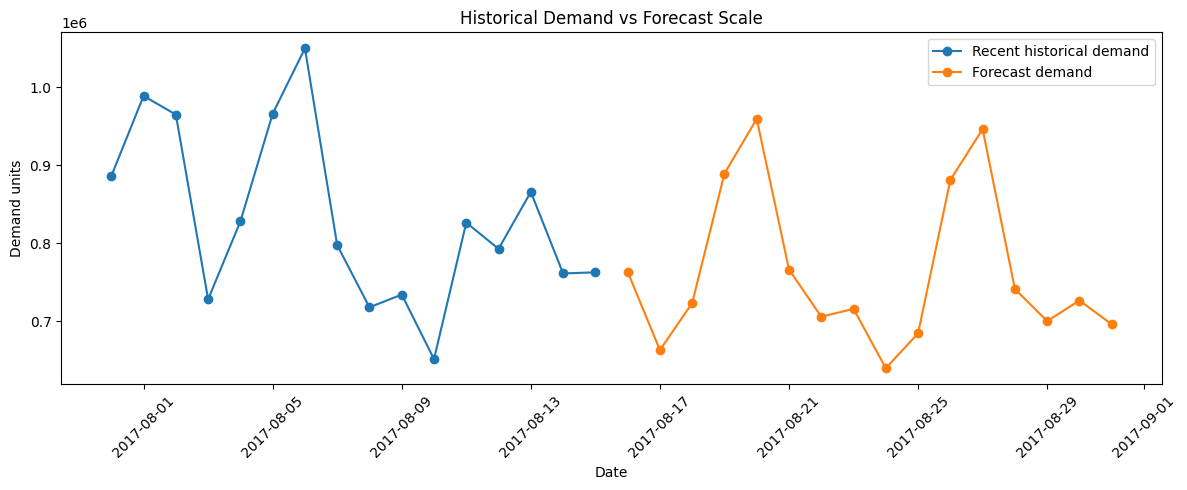

In [42]:
# Visualize historical versus forecast demand

plt.figure(figsize=(12, 5))

plt.plot(
    recent_history["date"],
    recent_history["historical_demand"],
    marker="o",
    label="Recent historical demand"
)

plt.plot(
    daily_forecast["date"],
    daily_forecast["total_forecast_units"],
    marker="o",
    label="Forecast demand"
)

plt.xlabel("Date")
plt.ylabel("Demand units")
plt.title("Historical Demand vs Forecast Scale")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# Prepare final validation predictions

model = joblib.load(MODEL_PATH)

validation_start = pd.Timestamp("2017-07-31")
validation_end = pd.Timestamp("2017-08-15")

validation_data = con.execute(f"""
SELECT
    *
FROM read_parquet('{FEATURES_PATH.as_posix()}')
WHERE date BETWEEN
    DATE '{validation_start.strftime("%Y-%m-%d")}'
    AND DATE '{validation_end.strftime("%Y-%m-%d")}'
    AND lag_28 IS NOT NULL
""").df()

validation_data["family"] = validation_data["family"].astype(
    pd.CategoricalDtype(
        categories=model.booster_.pandas_categorical[0]
    )
)

validation_data["store_nbr"] = validation_data["store_nbr"].astype(int)

X_val = validation_data[FEATURE_COLUMNS].copy()

X_val["family"] = X_val["family"].astype(
    pd.CategoricalDtype(
        categories=model.booster_.pandas_categorical[0]
    )
)

X_val["store_nbr"] = X_val["store_nbr"].astype(int)

validation_data["prediction"] = np.maximum(
    model.predict(X_val),
    0
)

print("Validation rows:", len(validation_data))
display(validation_data.head())

Validation rows: 25783


,date,store_nbr,family,target_demand_units,missing_observation_flag,promotion_rate,promotion_data_available,promoted_records,promotion_known_records,day_of_week,...,oil_missing,lag_1,lag_7,lag_14,lag_28,lag_364,rolling_mean_7,rolling_mean_28,rolling_std_28,prediction
0,2017-07-31,27,HOME CARE,304.0,0,0.142857,1,9.0,63,1,...,0,434.0,455.0,300.0,314.0,238.0,308.857143,274.642857,87.324942,355.752095
1,2017-08-01,27,HOME CARE,328.0,0,0.100000,1,6.0,60,2,...,0,304.0,290.0,255.0,248.0,200.0,287.285714,274.285714,87.178343,318.765707
2,2017-08-02,27,HOME CARE,258.0,0,0.105263,1,6.0,57,3,...,0,328.0,265.0,316.0,244.0,243.0,292.714286,277.142857,87.594907,302.446045
3,2017-08-03,27,HOME CARE,170.0,0,0.096154,1,5.0,52,4,...,0,258.0,199.0,195.0,168.0,155.0,291.714286,277.642857,87.438535,234.224505
4,2017-08-04,27,HOME CARE,144.0,0,0.120000,1,6.0,50,5,...,0,170.0,230.0,190.0,176.0,143.0,287.571429,277.714286,87.346419,231.061400


In [44]:
# Calculate validation forecast errors

validation_data["error"] = (
    validation_data["prediction"]
    - validation_data["target_demand_units"]
)

validation_data["absolute_error"] = validation_data["error"].abs()

validation_data["squared_error"] = (
    validation_data["error"] ** 2
)

validation_summary = pd.DataFrame({
    "MAE": [
        validation_data["absolute_error"].mean()
    ],
    "RMSE": [
        np.sqrt(validation_data["squared_error"].mean())
    ],
    "Bias": [
        validation_data["error"].mean()
    ],
    "Actual_demand": [
        validation_data["target_demand_units"].sum()
    ],
    "Forecast_demand": [
        validation_data["prediction"].sum()
    ]
})

validation_summary["WAPE"] = (
    validation_data["absolute_error"].sum()
    / validation_data["target_demand_units"].sum()
)

display(validation_summary)

,MAE,RMSE,Bias,Actual_demand,Forecast_demand,WAPE
0,69.09175,214.578716,14.360569,1.331983e+07,1.369009e+07,0.13374


In [45]:
# Estimate forecast uncertainty

error_std = validation_data["error"].std()
error_mae = validation_data["absolute_error"].mean()

print("Validation error standard deviation:", error_std)
print("Validation MAE:", error_mae)
print("Validation bias:", validation_data["error"].mean())

error_by_horizon = (
    validation_data
    .groupby("date")
    .agg(
        mae=("absolute_error", "mean"),
        bias=("error", "mean")
    )
    .reset_index()
)

display(error_by_horizon)

Validation error standard deviation: 214.10179163353104
Validation MAE: 69.09175024701184
Validation bias: 14.36056883489799


,date,mae,bias
0,2017-07-31,63.349192,6.984194
1,2017-08-01,73.074929,-35.258487
2,2017-08-02,64.764746,-18.319169
3,2017-08-03,69.917908,40.896096
4,2017-08-04,67.017892,18.038631
5,2017-08-05,85.540941,66.973228
6,2017-08-06,83.757660,32.866295
7,2017-08-07,55.396562,12.589727
8,2017-08-08,59.087021,24.550897
9,2017-08-09,49.763308,13.128475


In [46]:
# Save validation error artifact

VALIDATION_PATH = PROCESSED_DIR / "validation_predictions.parquet"

validation_data[
    [
        "date",
        "store_nbr",
        "family",
        "target_demand_units",
        "prediction",
        "error",
        "absolute_error"
    ]
].to_parquet(
    VALIDATION_PATH,
    index=False
)

print("Saved:", VALIDATION_PATH)
print("Rows saved:", len(validation_data))

Saved: C:\Users\dell\demand-forecasting-inventory\data\processed\validation_predictions.parquet
Rows saved: 25783


In [47]:
# Define inventory assumptions

INVENTORY_LEAD_TIME_DAYS = 7
INVENTORY_SERVICE_LEVEL = 0.95

# z-score for 95% service level
SERVICE_Z = 1.645

print("Lead time:", INVENTORY_LEAD_TIME_DAYS, "days")
print("Service level:", INVENTORY_SERVICE_LEVEL)
print("Safety-stock z:", SERVICE_Z)

Lead time: 7 days
Service level: 0.95
Safety-stock z: 1.645


In [48]:
# Calculate series-level forecast uncertainty

series_error_stats = (
    validation_data
    .groupby(["store_nbr", "family"])
    .agg(
        error_std=("error", "std"),
        mean_error=("error", "mean"),
        validation_rows=("error", "count")
    )
    .reset_index()
)

global_error_std = validation_data["error"].std()

series_error_stats["error_std"] = (
    series_error_stats["error_std"]
    .fillna(global_error_std)
)

print("Series with validation errors:", len(series_error_stats))
print("Global error std:", global_error_std)

display(series_error_stats.head())

Series with validation errors: 1782
Global error std: 214.10179163353104


C:\Users\dell\AppData\Local\Temp\ipykernel_11592\1597674910.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["store_nbr", "family"])


,store_nbr,family,error_std,mean_error,validation_rows
0,1,AUTOMOTIVE,3.274480,-1.063849,16
1,1,BABY CARE,214.101792,NaN,0
2,1,BEAUTY,8.292662,5.641114,16
3,1,BEVERAGES,391.032637,127.171986,16
4,1,BOOKS,214.101792,4.777658,1


In [49]:
# Build inventory demand inputs

forecast_demand_by_series = (
    test_forecast_final
    .groupby(["store_nbr", "family"])
    .agg(
        forecast_total_units=("forecast_demand_units", "sum"),
        forecast_daily_mean=("forecast_demand_units", "mean")
    )
    .reset_index()
)

inventory_inputs = forecast_demand_by_series.merge(
    series_error_stats,
    on=["store_nbr", "family"],
    how="left"
)

inventory_inputs["error_std"] = (
    inventory_inputs["error_std"]
    .fillna(global_error_std)
)

display(inventory_inputs.head())

,store_nbr,family,forecast_total_units,forecast_daily_mean,error_std,mean_error,validation_rows
0,1,AUTOMOTIVE,58.011876,3.625742,3.274480,-1.063849,16
1,1,BABY CARE,0.000000,0.000000,214.101792,NaN,0
2,1,BEAUTY,101.575943,6.348496,8.292662,5.641114,16
3,1,BEVERAGES,30129.772019,1883.110751,391.032637,127.171986,16
4,1,BOOKS,42.233834,2.639615,214.101792,4.777658,1


In [52]:
# Rebuild inventory inputs

forecast_demand_by_series = (
    test_forecast_final
    .groupby(["store_nbr", "family"])
    .agg(
        forecast_total_units=("forecast_demand_units", "sum"),
        forecast_daily_mean=("forecast_demand_units", "mean")
    )
    .reset_index()
)

series_error_stats = (
    validation_data
    .groupby(["store_nbr", "family"])
    .agg(
        error_std=("error", "std"),
        mean_error=("error", "mean"),
        validation_rows=("error", "count")
    )
    .reset_index()
)

global_error_std = validation_data["error"].std()

inventory_inputs = forecast_demand_by_series.merge(
    series_error_stats,
    on=["store_nbr", "family"],
    how="left"
)

inventory_inputs["error_std"] = (
    inventory_inputs["error_std"]
    .fillna(global_error_std)
)

print("Inventory series:", len(inventory_inputs))
print("Global error std:", global_error_std)

Inventory series: 1782
Global error std: 214.10179163353104


C:\Users\dell\AppData\Local\Temp\ipykernel_11592\243398152.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["store_nbr", "family"])


In [53]:
# Calculate safety stock

INVENTORY_LEAD_TIME_DAYS = 7
INVENTORY_SERVICE_LEVEL = 0.95
SERVICE_Z = 1.645

inventory_inputs["safety_stock"] = (
    SERVICE_Z
    * inventory_inputs["error_std"]
    * np.sqrt(INVENTORY_LEAD_TIME_DAYS)
)

inventory_inputs["lead_time_demand"] = (
    inventory_inputs["forecast_daily_mean"]
    * INVENTORY_LEAD_TIME_DAYS
)

inventory_inputs["reorder_point"] = (
    inventory_inputs["lead_time_demand"]
    + inventory_inputs["safety_stock"]
)

inventory_inputs["recommended_order_quantity"] = (
    inventory_inputs["reorder_point"].clip(lower=0)
)

print("Safety stock calculated.")
print("Reorder point calculated.")

Safety stock calculated.
Reorder point calculated.


In [54]:
# Validate inventory calculations

print("Null safety stock:", inventory_inputs["safety_stock"].isna().sum())
print("Null reorder point:", inventory_inputs["reorder_point"].isna().sum())
print("Negative safety stock:", (inventory_inputs["safety_stock"] < 0).sum())
print("Negative reorder point:", (inventory_inputs["reorder_point"] < 0).sum())

assert inventory_inputs["safety_stock"].isna().sum() == 0
assert inventory_inputs["reorder_point"].isna().sum() == 0
assert (inventory_inputs["safety_stock"] < 0).sum() == 0
assert (inventory_inputs["reorder_point"] < 0).sum() == 0

Null safety stock: 0
Null reorder point: 0
Negative safety stock: 0
Negative reorder point: 0


In [55]:
# Save inventory recommendations

INVENTORY_PATH = PROCESSED_DIR / "inventory_recommendations.parquet"

inventory_inputs.to_parquet(
    INVENTORY_PATH,
    index=False
)

print("Saved:", INVENTORY_PATH)
print("Rows:", len(inventory_inputs))
print("File exists:", INVENTORY_PATH.exists())

display(
    inventory_inputs[
        [
            "store_nbr",
            "family",
            "forecast_daily_mean",
            "error_std",
            "safety_stock",
            "lead_time_demand",
            "reorder_point"
        ]
    ]
    .sort_values("reorder_point", ascending=False)
    .head(10)
)

Saved: C:\Users\dell\demand-forecasting-inventory\data\processed\inventory_recommendations.parquet
Rows: 1782
File exists: True


,store_nbr,family,forecast_daily_mean,error_std,safety_stock,lead_time_demand,reorder_point
1464,45,GROCERY I,9841.106850,819.394749,3566.219735,68887.747948,72453.967682
1422,44,BEVERAGES,9150.373422,1282.377439,5581.241194,64052.613955,69633.855149
1449,44,PRODUCE,9226.566694,842.271703,3665.786204,64585.966857,68251.753061
1431,44,GROCERY I,9110.630539,949.026590,4130.411326,63774.413773,67904.825099
1530,47,GROCERY I,9029.727942,1024.089858,4457.106252,63208.095591,67665.201843
1455,45,BEVERAGES,8463.331596,1043.995663,4543.741509,59243.321170,63787.062680
1497,46,GROCERY I,8236.375880,927.390788,4036.246673,57654.631162,61690.877834
1521,47,BEVERAGES,7752.533118,1288.582030,5608.245193,54267.731829,59875.977021
69,3,BEVERAGES,7748.168652,748.013326,3255.549157,54237.180567,57492.729724
1614,49,PRODUCE,7478.619565,692.058817,3012.020535,52350.336957,55362.357492


In [56]:
# Project bootstrap

from pathlib import Path
import sys
import json
import joblib
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"C:\Users\dell\demand-forecasting-inventory")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CONFIGS_DIR = PROJECT_ROOT / "configs"
MODELS_DIR = PROJECT_ROOT / "models"

MODEL_BASE_PATH = PROCESSED_DIR / "model_base.parquet"
FEATURES_PATH = PROCESSED_DIR / "forecast_features.parquet"
BASELINE_PATH = PROCESSED_DIR / "baseline_results.parquet"
FORECAST_PATH = PROCESSED_DIR / "test_store_family_forecast.parquet"
VALIDATION_PATH = PROCESSED_DIR / "validation_predictions.parquet"
INVENTORY_PATH = PROCESSED_DIR / "inventory_recommendations.parquet"

SPLITS_PATH = CONFIGS_DIR / "forecasting_splits.json"
MODEL_PATH = MODELS_DIR / "lightgbm_forecaster.joblib"

con = duckdb.connect()
con.execute("SET threads = 2")
con.execute("SET memory_limit = '3GB'")

print("Notebook 2 initialized")
print("Project:", PROJECT_ROOT)

Notebook 2 initialized
Project: C:\Users\dell\demand-forecasting-inventory


In [57]:
# Restore forecasting configuration

FEATURE_COLUMNS = [
    "store_nbr",
    "family",
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "year",
    "week_of_year",
    "is_weekend",
    "is_holiday",
    "oil_price",
    "oil_missing",
    "promotion_rate",
    "promotion_data_available",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "lag_364",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_std_28"
]

TARGET_COLUMN = "target_demand_units"

with open(SPLITS_PATH, "r") as f:
    saved_splits = json.load(f)

model = joblib.load(MODEL_PATH)

print("Configuration restored")
print("Features:", len(FEATURE_COLUMNS))
print("Model:", type(model).__name__)
print("Target:", TARGET_COLUMN)

Configuration restored
Features: 22
Model: LGBMRegressor
Target: target_demand_units


In [58]:
# Verify persisted forecasting artifacts

artifacts = {
    "model base": MODEL_BASE_PATH,
    "forecast features": FEATURES_PATH,
    "baselines": BASELINE_PATH,
    "test forecast": FORECAST_PATH,
    "validation predictions": VALIDATION_PATH,
    "inventory recommendations": INVENTORY_PATH,
    "model": MODEL_PATH,
    "forecasting splits": SPLITS_PATH,
}

for name, path in artifacts.items():
    print(f"{name:25} {'OK' if path.exists() else 'MISSING'}")

model base                OK
forecast features         OK
baselines                 OK
test forecast             OK
validation predictions    OK
inventory recommendations OK
model                     OK
forecasting splits        OK


In [59]:
# Load final forecasting artifacts

forecast = pd.read_parquet(FORECAST_PATH)
validation = pd.read_parquet(VALIDATION_PATH)
inventory = pd.read_parquet(INVENTORY_PATH)
baseline_results = pd.read_parquet(BASELINE_PATH)

print("Forecast rows:", len(forecast))
print("Validation rows:", len(validation))
print("Inventory rows:", len(inventory))
print("Baseline rows:", len(baseline_results))

print("\nForecast dates:")
print(forecast["date"].min(), "→", forecast["date"].max())

print("\nForecast columns:")
print(forecast.columns.tolist())

Forecast rows: 28512
Validation rows: 25783
Inventory rows: 1782
Baseline rows: 6

Forecast dates:
2017-08-16 00:00:00 → 2017-08-31 00:00:00

Forecast columns:
['date', 'store_nbr', 'family', 'forecast_demand_units']


In [60]:
# Inspect baseline results

print("Baseline columns:")
print(baseline_results.columns.tolist())

print("\nBaseline results:")
display(baseline_results)

Baseline columns:
['window', 'model', 'MAE', 'RMSE', 'WAPE', 'rows_evaluated']

Baseline results:


,window,model,MAE,RMSE,WAPE,rows_evaluated
0,1,Naive-1,124.625388,406.787751,0.241236,25783
1,1,Seasonal-Naive-7,110.835893,368.201127,0.214543,25783
2,2,Naive-1,129.987875,432.833569,0.251772,26606
3,2,Seasonal-Naive-7,73.040381,275.621331,0.141460,26604
4,3,Naive-1,138.805554,494.933439,0.269786,26868
5,3,Seasonal-Naive-7,98.836161,366.512193,0.192072,26864


In [61]:
# Evaluate final validation performance

actual = validation["target_demand_units"].clip(lower=0)
prediction = validation["prediction"].clip(lower=0)

mae = np.mean(np.abs(actual - prediction))
rmse = np.sqrt(np.mean((actual - prediction) ** 2))
wape = np.sum(np.abs(actual - prediction)) / np.sum(np.abs(actual))

print(f"MAE :  {mae:,.3f}")
print(f"RMSE:  {rmse:,.3f}")
print(f"WAPE:  {wape:.2%}")

print("\nValidation period:")
print(validation["date"].min(), "→", validation["date"].max())
print("Validation rows:", len(validation))

MAE :  69.092
RMSE:  214.579
WAPE:  13.37%

Validation period:
2017-07-31 00:00:00 → 2017-08-15 00:00:00
Validation rows: 25783


In [62]:
# Analyze forecast behavior

forecast_summary = forecast.groupby("date").agg(
    total_forecast_units=("forecast_demand_units", "sum"),
    mean_series_forecast=("forecast_demand_units", "mean"),
    active_series=("forecast_demand_units", lambda x: (x > 0).sum())
).reset_index()

print("Forecast summary:")
display(forecast_summary)

print("\nTotal forecast units:", f"{forecast['forecast_demand_units'].sum():,.0f}")
print("Average daily forecast:", f"{forecast_summary['total_forecast_units'].mean():,.0f}")
print("Forecasted series:", forecast[["store_nbr", "family"]].drop_duplicates().shape[0])

Forecast summary:


,date,total_forecast_units,mean_series_forecast,active_series
0,2017-08-16,763340.814508,428.361849,1729
1,2017-08-17,663032.610750,372.072172,1729
2,2017-08-18,723345.329346,405.917693,1729
3,2017-08-19,889149.957492,498.961817,1729
4,2017-08-20,959173.721073,538.256858,1729
5,2017-08-21,766261.329422,430.000746,1729
6,2017-08-22,705823.252774,396.084878,1729
7,2017-08-23,715869.484593,401.722494,1729
8,2017-08-24,639871.516989,359.074925,1729
9,2017-08-25,684537.348758,384.139926,1729



Total forecast units: 12,201,554
Average daily forecast: 762,597
Forecasted series: 1782


In [63]:
# Inspect inventory recommendations

inventory_summary = inventory[
    [
        "store_nbr",
        "family",
        "forecast_total_units",
        "forecast_daily_mean",
        "error_std",
        "safety_stock",
        "lead_time_demand",
        "reorder_point",
        "recommended_order_quantity"
    ]
].sort_values(
    "recommended_order_quantity",
    ascending=False
)

print("Top 20 inventory recommendations:")
display(inventory_summary.head(20))

print("\nTotal recommended order quantity:",
      f"{inventory['recommended_order_quantity'].sum():,.0f}")

print("Average safety stock:",
      f"{inventory['safety_stock'].mean():,.2f}")

Top 20 inventory recommendations:


,store_nbr,family,forecast_total_units,forecast_daily_mean,error_std,safety_stock,lead_time_demand,reorder_point,recommended_order_quantity
1464,45,GROCERY I,157457.709595,9841.106850,819.394749,3566.219735,68887.747948,72453.967682,72453.967682
1422,44,BEVERAGES,146405.974754,9150.373422,1282.377439,5581.241194,64052.613955,69633.855149,69633.855149
1449,44,PRODUCE,147625.067102,9226.566694,842.271703,3665.786204,64585.966857,68251.753061,68251.753061
1431,44,GROCERY I,145770.088625,9110.630539,949.026590,4130.411326,63774.413773,67904.825099,67904.825099
1530,47,GROCERY I,144475.647064,9029.727942,1024.089858,4457.106252,63208.095591,67665.201843,67665.201843
1455,45,BEVERAGES,135413.305532,8463.331596,1043.995663,4543.741509,59243.321170,63787.062680,63787.062680
1497,46,GROCERY I,131782.014084,8236.375880,927.390788,4036.246673,57654.631162,61690.877834,61690.877834
1521,47,BEVERAGES,124040.529895,7752.533118,1288.582030,5608.245193,54267.731829,59875.977021,59875.977021
69,3,BEVERAGES,123970.698439,7748.168652,748.013326,3255.549157,54237.180567,57492.729724,57492.729724
1614,49,PRODUCE,119657.913043,7478.619565,692.058817,3012.020535,52350.336957,55362.357492,55362.357492



Total recommended order quantity: 6,067,019
Average safety stock: 409.00


In [64]:
# Model feature importance

feature_importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance)

,feature,importance
3,day_of_month,1026
14,lag_1,829
7,week_of_year,819
15,lag_7,684
10,oil_price,662
18,lag_364,615
16,lag_14,465
2,day_of_week,440
4,month,416
12,promotion_rate,413


In [65]:
# Validation error by product family

family_error = validation.groupby("family").agg(
    actual_units=("target_demand_units", "sum"),
    prediction_units=("prediction", "sum"),
    mae=("absolute_error", "mean"),
    mean_error=("error", "mean")
).reset_index()

family_error["abs_error_rate"] = (
    family_error["mae"] /
    family_error["actual_units"].replace(0, np.nan)
)

family_error = family_error.sort_values("mae", ascending=False)

display(family_error.head(15))

C:\Users\dell\AppData\Local\Temp\ipykernel_11592\2457298643.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  family_error = validation.groupby("family").agg(


,family,actual_units,prediction_units,mae,mean_error,abs_error_rate
3,BEVERAGES,3005506.000,3.073497e+06,490.559938,78.693617,0.000163
12,GROCERY I,3980786.484,4.054112e+06,468.457323,84.867275,0.000118
7,CLEANING,1065292.000,1.165414e+06,271.066552,115.881598,0.000254
30,PRODUCE,1977493.914,2.007424e+06,205.630400,34.640765,0.000104
8,DAIRY,721036.000,7.534498e+05,85.351475,37.515930,0.000118
5,BREAD/BAKERY,466842.501,4.754169e+05,61.635021,9.924061,0.000132
24,MEATS,321073.055,3.297040e+05,56.639950,9.989481,0.000176
25,PERSONAL CARE,277640.000,2.907653e+05,54.849027,15.191325,0.000198
18,HOME CARE,251904.000,2.733832e+05,52.615681,24.860165,0.000209
28,POULTRY,323560.269,3.373669e+05,51.045226,15.979905,0.000158


In [78]:
# Validation error by store

store_error = validation.groupby("store_nbr").agg(
    actual_units=("target_demand_units", "sum"),
    prediction_units=("prediction", "sum"),
    mae=("absolute_error", "mean"),
    mean_error=("error", "mean")
).reset_index()

store_error["abs_error_rate"] = (
    store_error["mae"] /
    store_error["actual_units"].replace(0, np.nan)
)

store_error = store_error.sort_values("mae", ascending=False)

display(store_error.head(15))

,store_nbr,actual_units,prediction_units,mae,mean_error,abs_error_rate
43,44,656658.858,704314.545426,150.607658,98.666020,0.000229
39,40,287750.831,277712.305982,134.786571,-21.966138,0.000468
46,47,581807.171,599635.580380,113.697809,36.163102,0.000195
44,45,631280.519,650659.969754,109.765497,39.150406,0.000174
27,28,260708.965,251009.109725,108.565781,-20.292584,0.000416
47,48,403752.960,422631.862509,107.740525,38.925572,0.000267
45,46,456764.591,479703.673433,99.294044,45.695383,0.000217
38,39,261722.221,273044.135779,96.161472,22.689208,0.000367
19,20,288873.733,280089.321463,95.702065,-17.890859,0.000331
51,52,365489.354,366955.573008,94.636618,3.010717,0.000259


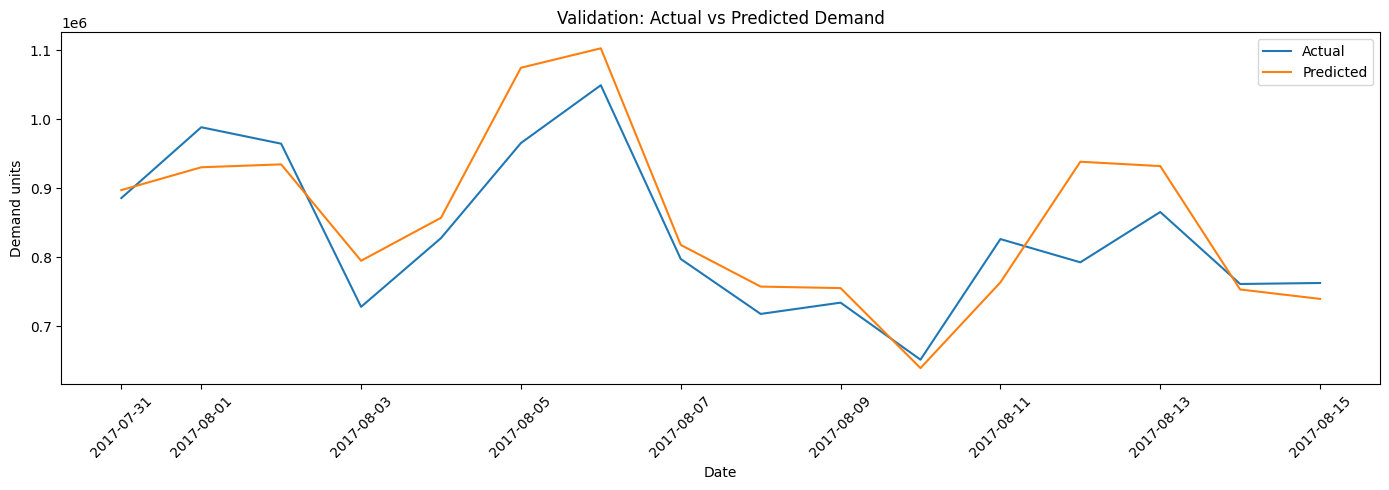

In [79]:
# Actual versus predicted demand over validation period

daily_validation = validation.groupby("date").agg(
    actual=("target_demand_units", "sum"),
    predicted=("prediction", "sum")
).reset_index()

plt.figure(figsize=(14, 5))

plt.plot(
    daily_validation["date"],
    daily_validation["actual"],
    label="Actual"
)

plt.plot(
    daily_validation["date"],
    daily_validation["predicted"],
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Demand units")
plt.title("Validation: Actual vs Predicted Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [80]:
# Compare forecasting methods

print("Baseline methods:")
print(baseline_results["model"].unique())

print("\nBaseline results:")
display(baseline_results)

Baseline methods:
['Naive-1' 'Seasonal-Naive-7']

Baseline results:


,window,model,MAE,RMSE,WAPE,rows_evaluated
0,1,Naive-1,124.625388,406.787751,0.241236,25783
1,1,Seasonal-Naive-7,110.835893,368.201127,0.214543,25783
2,2,Naive-1,129.987875,432.833569,0.251772,26606
3,2,Seasonal-Naive-7,73.040381,275.621331,0.141460,26604
4,3,Naive-1,138.805554,494.933439,0.269786,26868
5,3,Seasonal-Naive-7,98.836161,366.512193,0.192072,26864


In [81]:
# Compare LightGBM with the best baseline

baseline_metrics = baseline_results.copy()

if "wape" in baseline_metrics.columns:
    baseline_metrics["wape_pct"] = baseline_metrics["wape"] * 100

display(baseline_metrics)

print("\nLightGBM:")
print(f"MAE  : {mae:,.3f}")
print(f"RMSE : {rmse:,.3f}")
print(f"WAPE : {wape:.2%}")

,window,model,MAE,RMSE,WAPE,rows_evaluated
0,1,Naive-1,124.625388,406.787751,0.241236,25783
1,1,Seasonal-Naive-7,110.835893,368.201127,0.214543,25783
2,2,Naive-1,129.987875,432.833569,0.251772,26606
3,2,Seasonal-Naive-7,73.040381,275.621331,0.141460,26604
4,3,Naive-1,138.805554,494.933439,0.269786,26868
5,3,Seasonal-Naive-7,98.836161,366.512193,0.192072,26864



LightGBM:
MAE  : 69.092
RMSE : 214.579
WAPE : 13.37%


In [82]:
# Analyze systematic forecast bias

bias_summary = validation.groupby("date").agg(
    actual=("target_demand_units", "sum"),
    predicted=("prediction", "sum"),
    error=("error", "sum"),
    absolute_error=("absolute_error", "sum")
).reset_index()

bias_summary["bias_pct"] = (
    bias_summary["error"] /
    bias_summary["actual"].replace(0, np.nan)
)

print("Mean daily bias:",
      f"{bias_summary['error'].mean():,.2f}")

print("Overall bias:",
      f"{validation['error'].sum():,.2f}")

print("Mean absolute daily error:",
      f"{bias_summary['absolute_error'].mean():,.2f}")

Mean daily bias: 23,141.16
Overall bias: 370,258.55
Mean absolute daily error: 111,337.04


In [83]:
# Identify largest forecast errors

largest_errors = validation[
    [
        "date",
        "store_nbr",
        "family",
        "target_demand_units",
        "prediction",
        "error",
        "absolute_error"
    ]
].sort_values(
    "absolute_error",
    ascending=False
)

display(largest_errors.head(20))

,date,store_nbr,family,target_demand_units,prediction,error,absolute_error
14189,2017-08-12,28,GROCERY I,9841.523,5221.662939,-4619.860061,4619.860061
643,2017-08-06,54,BEVERAGES,8552.000,4056.753323,-4495.246677,4495.246677
9612,2017-08-12,47,BEVERAGES,7833.000,11773.342726,3940.342726,3940.342726
14613,2017-08-11,25,BEVERAGES,6318.000,2553.455033,-3764.544967,3764.544967
234,2017-08-12,40,GROCERY I,10739.000,7118.054637,-3620.945363,3620.945363
13428,2017-08-02,39,CLEANING,6263.000,2801.905155,-3461.094845,3461.094845
1954,2017-08-04,40,BEVERAGES,8272.000,4842.527105,-3429.472895,3429.472895
4963,2017-08-06,44,BEVERAGES,12913.000,16287.059902,3374.059902,3374.059902
14361,2017-08-12,33,BEVERAGES,5257.000,2074.032873,-3182.967127,3182.967127
7246,2017-08-01,38,BEVERAGES,6098.000,2916.385680,-3181.614320,3181.614320


In [84]:
# Final forecast sanity checks

print("Forecast rows:", len(forecast))
print("Expected rows:", 1782 * 16)

print("Unique dates:", forecast["date"].nunique())
print("Date range:", forecast["date"].min(), "→", forecast["date"].max())

print("Negative forecasts:", (forecast["forecast_demand_units"] < 0).sum())
print("Null forecasts:", forecast["forecast_demand_units"].isna().sum())

Forecast rows: 28512
Expected rows: 28512
Unique dates: 16
Date range: 2017-08-16 00:00:00 → 2017-08-31 00:00:00
Negative forecasts: 0
Null forecasts: 0


In [85]:
# Forecast distribution

print("Forecast statistics:")
display(
    forecast["forecast_demand_units"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nZero forecasts:",
      (forecast["forecast_demand_units"] == 0).sum())

print("Positive forecasts:",
      (forecast["forecast_demand_units"] > 0).sum())

Forecast statistics:


count    28512.000000
mean       427.944531
std       1140.905212
min          0.000000
50%         22.442662
75%        255.626685
90%       1117.435185
95%       2469.781369
99%       6072.805789
max      14119.208833
Name: forecast_demand_units, dtype: float64


Zero forecasts: 848
Positive forecasts: 27664


In [86]:
# Top forecast series

series_forecast = forecast.groupby(
    ["store_nbr", "family"]
).agg(
    total_forecast_units=("forecast_demand_units", "sum"),
    average_daily_demand=("forecast_demand_units", "mean")
).reset_index()

series_forecast["share_of_total"] = (
    series_forecast["total_forecast_units"] /
    series_forecast["total_forecast_units"].sum()
)

display(
    series_forecast.sort_values(
        "total_forecast_units",
        ascending=False
    ).head(20)
)

,store_nbr,family,total_forecast_units,average_daily_demand,share_of_total
1464,45,GROCERY I,157457.709595,9841.106850,0.012905
1449,44,PRODUCE,147625.067102,9226.566694,0.012099
1422,44,BEVERAGES,146405.974754,9150.373422,0.011999
1431,44,GROCERY I,145770.088625,9110.630539,0.011947
1530,47,GROCERY I,144475.647064,9029.727942,0.011841
1455,45,BEVERAGES,135413.305532,8463.331596,0.011098
1497,46,GROCERY I,131782.014084,8236.375880,0.010800
1521,47,BEVERAGES,124040.529895,7752.533118,0.010166
69,3,BEVERAGES,123970.698439,7748.168652,0.010160
1614,49,PRODUCE,119657.913043,7478.619565,0.009807


In [87]:
# Record final modeling assumptions

final_assumptions = {
    "forecast_grain": "store × product family × day",
    "forecast_horizon_days": 16,
    "model": "LightGBM global forecasting model",
    "validation": "walk-forward temporal validation",
    "target": "positive demand units; negative sales treated as returns/adjustments",
    "missing_active_series": "treated as zero recorded demand with missing-observation flag",
    "cold_start_series": "forecast set to zero when no historical series exists",
    "inventory_lead_time_days": 7,
    "inventory_service_level": 0.95,
    "transactions": "EDA/context only; not used as final forecast feature",
    "inventory_parameters": "assumed because actual lead time/service-level data are unavailable"
}

for key, value in final_assumptions.items():
    print(f"{key}: {value}")

forecast_grain: store × product family × day
forecast_horizon_days: 16
model: LightGBM global forecasting model
validation: walk-forward temporal validation
target: positive demand units; negative sales treated as returns/adjustments
missing_active_series: treated as zero recorded demand with missing-observation flag
cold_start_series: forecast set to zero when no historical series exists
inventory_lead_time_days: 7
inventory_service_level: 0.95
transactions: EDA/context only; not used as final forecast feature
inventory_parameters: assumed because actual lead time/service-level data are unavailable
